# Simulation Results Analysis

## Binary-Ta-NLP-Sector Simulation Results

In [57]:
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    _HAS_SEABORN = True
except Exception:
    _HAS_SEABORN = False

plt.style.use('seaborn-v0_8-whitegrid')


In [58]:
RESULTS_DIR = Path('../results/simulation/binary-ta-nlp-sector')
csv_paths = sorted(RESULTS_DIR.glob('*.csv'))
if not csv_paths:
    raise FileNotFoundError(f'No CSVs found in {RESULTS_DIR.resolve()}')

dfs = {}
for path in csv_paths:
    df = pd.read_csv(path)
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date')

    # Use filename stem as the primary label to avoid collisions
    mode = path.stem
    df['mode'] = mode
    dfs[mode] = df

list(dfs.keys())


['HYBRID_KELLY_MPT_H1_EE_OFF',
 'HYBRID_KELLY_MPT_H1_EE_ON',
 'HYBRID_KELLY_MPT_H5_EE_OFF',
 'HYBRID_KELLY_MPT_H5_EE_ON',
 'KELLY_ONLY_H1_EE_OFF',
 'KELLY_ONLY_H1_EE_ON',
 'KELLY_ONLY_H5_EE_OFF',
 'KELLY_ONLY_H5_EE_ON',
 'MPT_ONLY_H1_EE_OFF',
 'MPT_ONLY_H1_EE_ON',
 'MPT_ONLY_H5_EE_OFF',
 'MPT_ONLY_H5_EE_ON']

In [59]:
import re


def _parse_maybe(value):
    if isinstance(value, (list, dict)):
        return value
    if isinstance(value, float) and np.isnan(value):
        return None
    if isinstance(value, str):
        text = value.strip()
        text = re.sub(r"Timestamp\(\'([^']+)\'\)", r"'\1'", text)
        if text == '' or text.lower() == 'nan':
            return None
        if text[0] in '[{(' and text[-1] in ']})':
            try:
                return ast.literal_eval(text)
            except Exception:
                return None
    return value

def _ensure_returns(df):
    if 'daily_return' not in df.columns and {'equity_start', 'equity_end'}.issubset(df.columns):
        prev_end = df['equity_end'].shift(1).fillna(df['equity_start'])
        df['daily_return'] = (df['equity_start'] / prev_end) - 1.0
    return df

def _metrics_from_df(df, rf=0.0):
    df = df.copy()
    df = _ensure_returns(df)
    rets = df['daily_return'].astype(float).fillna(0.0).values
    if len(rets) == 0:
        return {}

    eq = df['equity_end'] if 'equity_end' in df.columns else None
    start_equity = df['equity_start'].iloc[0] if 'equity_start' in df.columns else np.nan
    end_equity = df['equity_end'].iloc[-1] if 'equity_end' in df.columns else np.nan

    total_return = (end_equity / start_equity - 1.0) if start_equity not in (0, np.nan) else np.nan
    n_days = len(rets)
    ann_factor = 252
    cagr = (1 + total_return) ** (ann_factor / n_days) - 1 if n_days > 0 and np.isfinite(total_return) else np.nan

    vol = np.std(rets, ddof=1) * np.sqrt(ann_factor) if n_days > 1 else np.nan
    mean_ret = np.mean(rets)
    sharpe = (mean_ret - rf / ann_factor) / (np.std(rets, ddof=1) + 1e-12) * np.sqrt(ann_factor) if n_days > 1 else np.nan

    downside = rets[rets < 0]
    sortino = (mean_ret - rf / ann_factor) / (np.std(downside, ddof=1) + 1e-12) * np.sqrt(ann_factor) if len(downside) > 1 else np.nan

    if eq is not None:
        roll_max = eq.cummax()
        drawdown = (eq / roll_max) - 1.0
        max_dd = drawdown.min() if len(drawdown) else np.nan
    else:
        max_dd = np.nan

    win_rate = float(np.mean(rets > 0)) if n_days else np.nan
    avg_win = np.mean(rets[rets > 0]) if np.any(rets > 0) else np.nan
    avg_loss = np.mean(rets[rets < 0]) if np.any(rets < 0) else np.nan
    profit_factor = -np.sum(rets[rets > 0]) / (np.sum(rets[rets < 0]) - 1e-12) if np.any(rets < 0) else np.nan

    return {
        'days': n_days,
        'start_equity': start_equity,
        'end_equity': end_equity,
        'total_return': total_return,
        'CAGR': cagr,
        'volatility': vol,
        'sharpe': sharpe,
        'sortino': sortino,
        'max_drawdown': max_dd,
        'win_rate': win_rate,
        'avg_win': avg_win,
        'avg_loss': avg_loss,
        'profit_factor': profit_factor,
    }


In [60]:
summary_rows = []
for mode, df in dfs.items():
    metrics = _metrics_from_df(df)
    metrics['mode'] = mode
    summary_rows.append(metrics)

summary_df = pd.DataFrame(summary_rows).set_index('mode').sort_values('total_return', ascending=False)
summary_df


,days,start_equity,end_equity,total_return,CAGR,volatility,sharpe,sortino,max_drawdown,win_rate,avg_win,avg_loss,profit_factor
mode,,,,,,,,,,,,,
MPT_ONLY_H5_EE_OFF,100,100000.0,104038.639198,0.040386,0.104919,0.037428,2.684752,3.675619,-0.028732,0.46,0.002197,-0.001749,1.651480
MPT_ONLY_H5_EE_ON,100,100000.0,104038.639198,0.040386,0.104919,0.037428,2.684752,3.675619,-0.028732,0.46,0.002197,-0.001749,1.651480
HYBRID_KELLY_MPT_H5_EE_OFF,100,100000.0,103684.351629,0.036844,0.095462,0.036229,2.535028,3.268657,-0.031594,0.55,0.001787,-0.001627,1.589450
HYBRID_KELLY_MPT_H5_EE_ON,100,100000.0,103684.351629,0.036844,0.095462,0.036229,2.535028,3.268657,-0.031594,0.55,0.001787,-0.001627,1.589450
KELLY_ONLY_H5_EE_OFF,100,100000.0,102155.739453,0.021557,0.055218,0.031397,1.727564,2.238693,-0.026777,0.37,0.002000,-0.001944,1.410089
KELLY_ONLY_H5_EE_ON,100,100000.0,102155.739453,0.021557,0.055218,0.031397,1.727564,2.238693,-0.026777,0.37,0.002000,-0.001944,1.410089
HYBRID_KELLY_MPT_H1_EE_OFF,100,100000.0,101110.338228,0.011103,0.028217,0.023426,1.199480,1.957466,-0.010575,0.52,0.001226,-0.001119,1.212003
HYBRID_KELLY_MPT_H1_EE_ON,100,100000.0,101110.338228,0.011103,0.028217,0.023426,1.199480,1.957466,-0.010575,0.52,0.001226,-0.001119,1.212003
MPT_ONLY_H1_EE_OFF,100,100000.0,101000.149369,0.010001,0.025396,0.026880,0.946339,1.535582,-0.013773,0.52,0.001386,-0.001319,1.162827


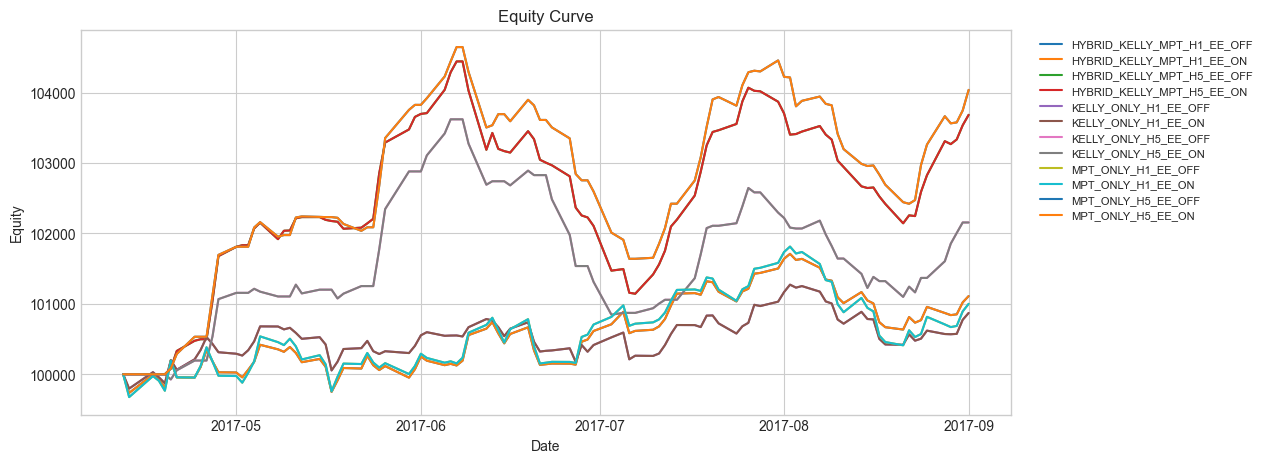

In [61]:
fig, ax = plt.subplots(figsize=(12, 5))
for mode, df in dfs.items():
    if 'equity_end' in df.columns:
        ax.plot(df['date'], df['equity_end'], label=mode)
ax.set_title('Equity Curve')
ax.set_xlabel('Date')
ax.set_ylabel('Equity')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()


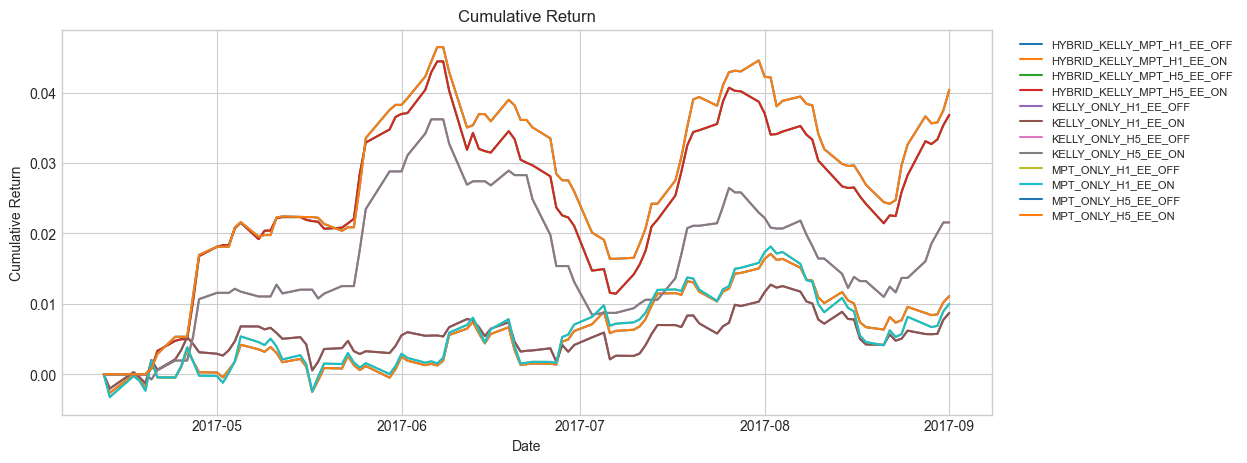

In [62]:
fig, ax = plt.subplots(figsize=(12, 5))
for mode, df in dfs.items():
    if 'equity_end' in df.columns and 'equity_start' in df.columns:
        base = df['equity_start'].iloc[0]
        ax.plot(df['date'], df['equity_end'] / base - 1.0, label=mode)
ax.set_title('Cumulative Return')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()


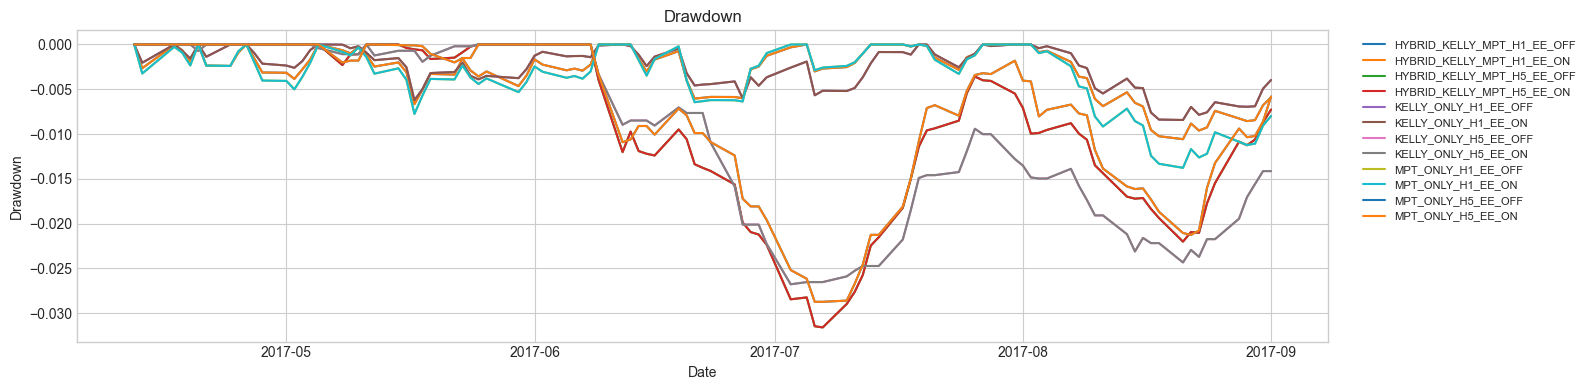

In [63]:
fig, ax = plt.subplots(figsize=(16, 4))
for mode, df in dfs.items():
    if 'equity_end' in df.columns:
        roll_max = df['equity_end'].cummax()
        drawdown = df['equity_end'] / roll_max - 1.0
        ax.plot(df['date'], drawdown, label=mode)
ax.set_title('Drawdown')
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


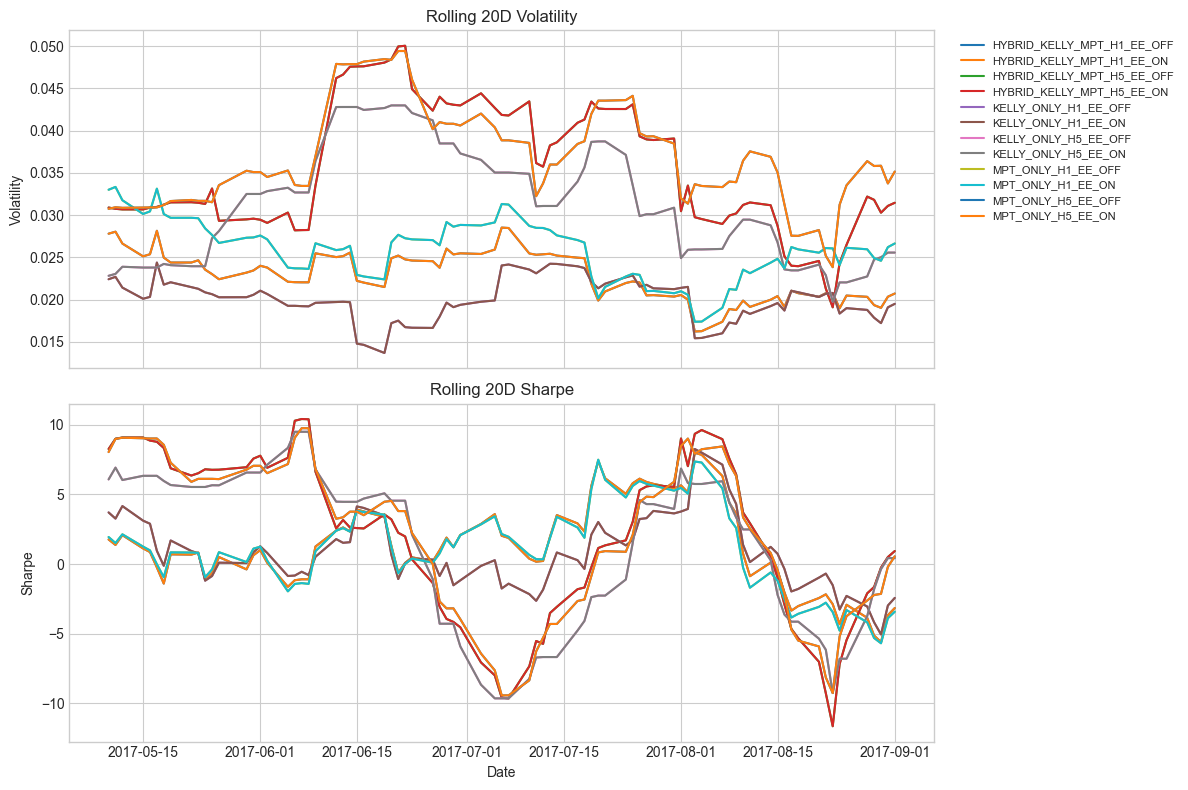

In [64]:
window = 20
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for mode, df in dfs.items():
    df = _ensure_returns(df)
    rets = df['daily_return'].astype(float).fillna(0.0)
    roll_vol = rets.rolling(window).std() * np.sqrt(252)
    roll_sharpe = rets.rolling(window).mean() / (rets.rolling(window).std() + 1e-12) * np.sqrt(252)
    axes[0].plot(df['date'], roll_vol, label=mode)
    axes[1].plot(df['date'], roll_sharpe, label=mode)

axes[0].set_title(f'Rolling {window}D Volatility')
axes[0].set_ylabel('Volatility')
axes[1].set_title(f'Rolling {window}D Sharpe')
axes[1].set_ylabel('Sharpe')
axes[1].set_xlabel('Date')
axes[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


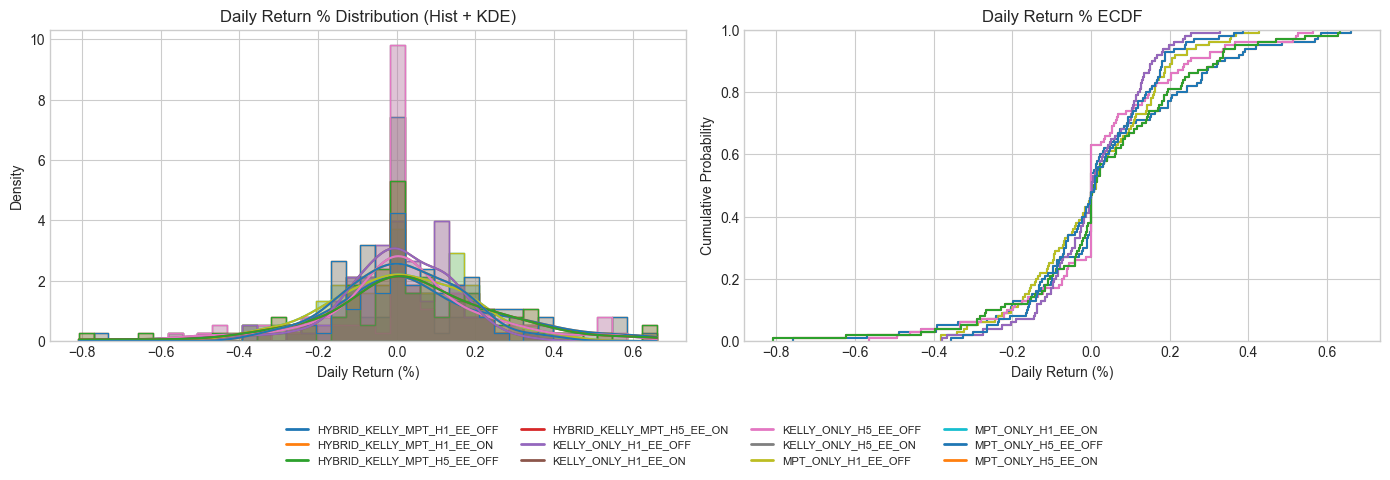

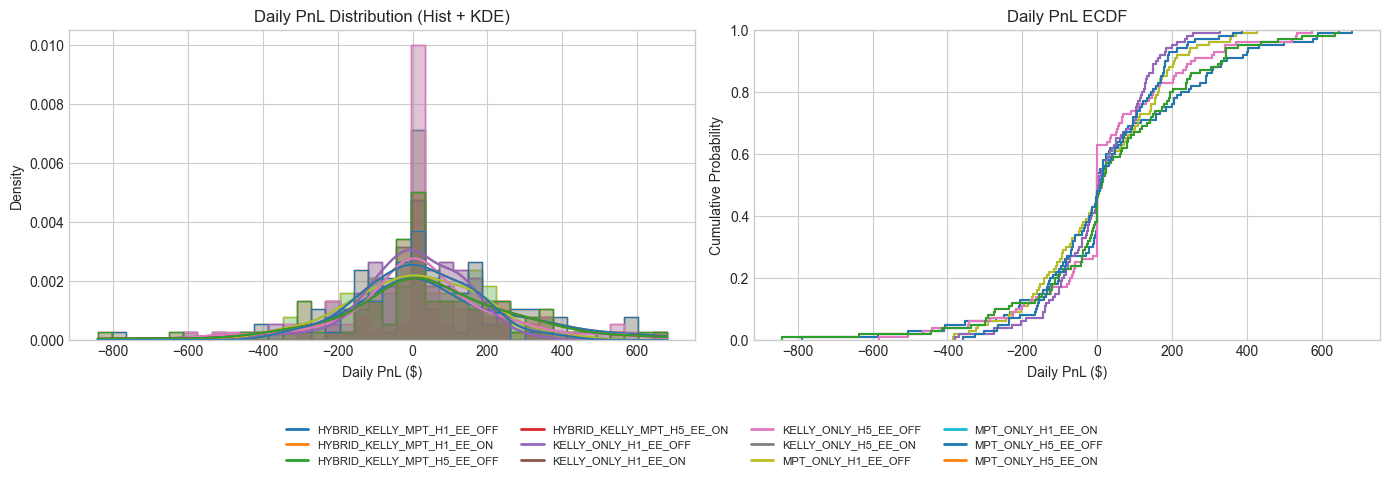

,max_abs_diff,mean_abs_diff,csv_nonnull,calc_nonnull
mode,,,,
HYBRID_KELLY_MPT_H1_EE_OFF,4.935288e-16,1.410153e-16,100,100
HYBRID_KELLY_MPT_H1_EE_ON,4.935288e-16,1.410153e-16,100,100
HYBRID_KELLY_MPT_H5_EE_OFF,4.440892e-16,1.401888e-16,100,100
HYBRID_KELLY_MPT_H5_EE_ON,4.440892e-16,1.401888e-16,100,100
KELLY_ONLY_H1_EE_OFF,4.981638e-16,1.590668e-16,100,100
KELLY_ONLY_H1_EE_ON,4.981638e-16,1.590668e-16,100,100
KELLY_ONLY_H5_EE_OFF,4.291272e-16,7.365311e-17,100,100
KELLY_ONLY_H5_EE_ON,4.291272e-16,7.365311e-17,100,100
MPT_ONLY_H1_EE_OFF,5.180318e-16,1.617722e-16,100,100


In [65]:
def _calc_daily_return(df):
    df = df.copy()
    if 'equity_end' in df.columns:
        prev_end = df['equity_end'].shift(1)
        if 'equity_start' in df.columns:
            prev_end = prev_end.fillna(df['equity_start'])
        else:
            prev_end = prev_end.fillna(df['equity_end'])
        return (df['equity_end'] / prev_end) - 1.0
    if 'daily_pnl_realized' in df.columns and 'equity_start' in df.columns:
        prev_end = df['equity_start'].shift(1).fillna(df['equity_start'])
        return df['daily_pnl_realized'] / prev_end
    if 'daily_return' in df.columns:
        return df['daily_return'].astype(float)
    return pd.Series(np.nan, index=df.index)

all_returns = []
pnl_rows = []
diag_rows = []
for mode, df in dfs.items():
    df = df.copy()
    csv_returns = df['daily_return'].astype(float) if 'daily_return' in df.columns else pd.Series(np.nan, index=df.index)
    calc_returns = _calc_daily_return(df).astype(float)

    diff = (csv_returns - calc_returns).abs()
    diag_rows.append({
        'mode': mode,
        'max_abs_diff': diff.max(),
        'mean_abs_diff': diff.mean(),
        'csv_nonnull': csv_returns.notna().sum(),
        'calc_nonnull': calc_returns.notna().sum(),
    })

    all_returns.append(pd.DataFrame({'mode': mode, 'daily_return': calc_returns}))
    if 'daily_pnl_realized' in df.columns:
        pnl_rows.append(pd.DataFrame({'mode': mode, 'daily_pnl': df['daily_pnl_realized'].astype(float)}))

returns_df = pd.concat(all_returns, ignore_index=True)
returns_df = returns_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['daily_return'])
returns_df['daily_return_pct'] = returns_df['daily_return'] * 100.0

pnl_df = pd.concat(pnl_rows, ignore_index=True) if pnl_rows else pd.DataFrame(columns=['mode', 'daily_pnl'])
pnl_df = pnl_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['daily_pnl'])

# Build a color map that covers all modes present
mode_order = sorted(returns_df['mode'].unique())
if _HAS_SEABORN:
    palette = sns.color_palette('tab10', n_colors=max(len(mode_order), 1))
else:
    palette = plt.cm.tab10.colors if len(mode_order) <= 10 else plt.cm.tab20.colors
mode_color_map = {mode: palette[i % len(palette)] for i, mode in enumerate(mode_order)}

# -------------------- RETURNS FIGURE --------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Returns: histogram + KDE
if _HAS_SEABORN:
    sns.histplot(data=returns_df, x='daily_return_pct', hue='mode', element='step', stat='density',
                 common_norm=False, kde=True, palette=mode_color_map, ax=axes[0], legend=False)
else:
    for mode in returns_df['mode'].unique():
        subset = returns_df[returns_df['mode'] == mode]['daily_return_pct']
        axes[0].hist(subset, bins=30, alpha=0.35, label=mode, density=True, color=mode_color_map.get(mode))
axes[0].set_title('Daily Return % Distribution (Hist + KDE)')
axes[0].set_xlabel('Daily Return (%)')
axes[0].set_ylabel('Density')

# Returns: ECDF
if _HAS_SEABORN:
    sns.ecdfplot(data=returns_df, x='daily_return_pct', hue='mode', palette=mode_color_map, ax=axes[1], legend=False)
else:
    for mode in returns_df['mode'].unique():
        subset = np.sort(returns_df[returns_df['mode'] == mode]['daily_return_pct'].values)
        y = np.arange(1, len(subset) + 1) / len(subset)
        axes[1].plot(subset, y, label=mode, color=mode_color_map.get(mode))
axes[1].set_title('Daily Return % ECDF')
axes[1].set_xlabel('Daily Return (%)')
axes[1].set_ylabel('Cumulative Probability')

# Shared legend below the returns plots
handles = [plt.Line2D([0], [0], color=mode_color_map[m], lw=2) for m in mode_order]
fig.legend(handles, mode_order, loc='upper center', bbox_to_anchor=(0.5, -0.05),
           ncol=min(len(mode_order), 4), frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# -------------------- PNL FIGURE --------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# PnL: histogram + KDE
if not pnl_df.empty:
    if _HAS_SEABORN:
        sns.histplot(data=pnl_df, x='daily_pnl', hue='mode', element='step', stat='density',
                     common_norm=False, kde=True, palette=mode_color_map, ax=axes[0], legend=False)
    else:
        for mode in pnl_df['mode'].unique():
            subset = pnl_df[pnl_df['mode'] == mode]['daily_pnl']
            axes[0].hist(subset, bins=30, alpha=0.35, label=mode, density=True, color=mode_color_map.get(mode))
    axes[0].set_title('Daily PnL Distribution (Hist + KDE)')
    axes[0].set_xlabel('Daily PnL ($)')
    axes[0].set_ylabel('Density')
else:
    axes[0].text(0.5, 0.5, 'No daily_pnl_realized column found', ha='center', va='center')
    axes[0].set_axis_off()

# PnL: ECDF
if not pnl_df.empty:
    if _HAS_SEABORN:
        sns.ecdfplot(data=pnl_df, x='daily_pnl', hue='mode', palette=mode_color_map, ax=axes[1], legend=False)
    else:
        for mode in pnl_df['mode'].unique():
            subset = np.sort(pnl_df[pnl_df['mode'] == mode]['daily_pnl'].values)
            y = np.arange(1, len(subset) + 1) / len(subset)
            axes[1].plot(subset, y, label=mode, color=mode_color_map.get(mode))
    axes[1].set_title('Daily PnL ECDF')
    axes[1].set_xlabel('Daily PnL ($)')
    axes[1].set_ylabel('Cumulative Probability')
else:
    axes[1].text(0.5, 0.5, 'No daily_pnl_realized column found', ha='center', va='center')
    axes[1].set_axis_off()

# Shared legend below the pnl plots
if not pnl_df.empty:
    fig.legend(handles, mode_order, loc='upper center', bbox_to_anchor=(0.5, -0.05),
               ncol=min(len(mode_order), 4), frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

pd.DataFrame(diag_rows).set_index('mode')


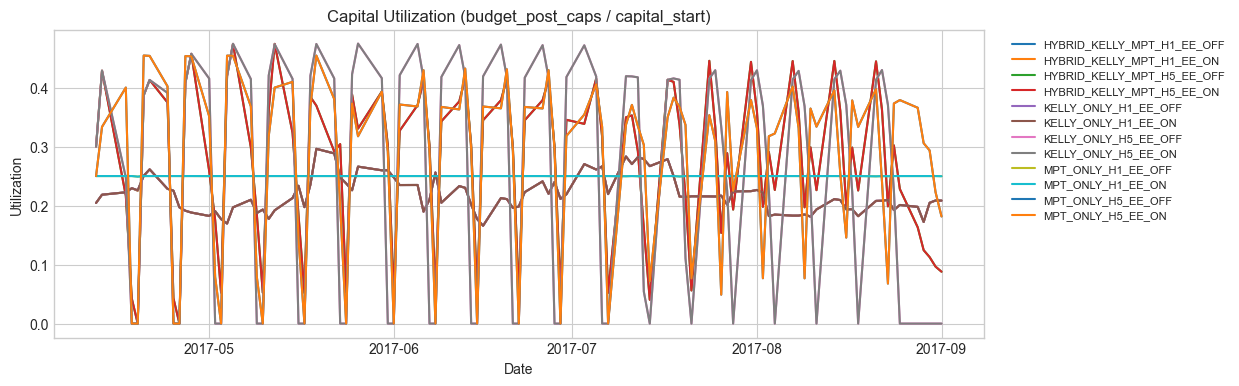

In [66]:
fig, ax = plt.subplots(figsize=(12, 4))
for mode, df in dfs.items():
    if {'budget_post_caps', 'capital_start'}.issubset(df.columns):
        utilization = df['budget_post_caps'] / df['capital_start']
        ax.plot(df['date'], utilization, label=mode)
ax.set_title('Capital Utilization (budget_post_caps / capital_start)')
ax.set_xlabel('Date')
ax.set_ylabel('Utilization')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()


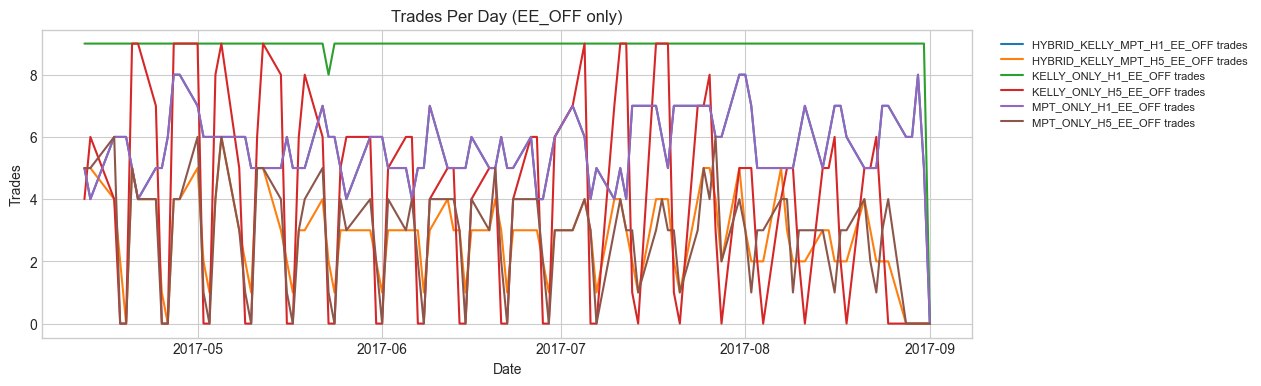

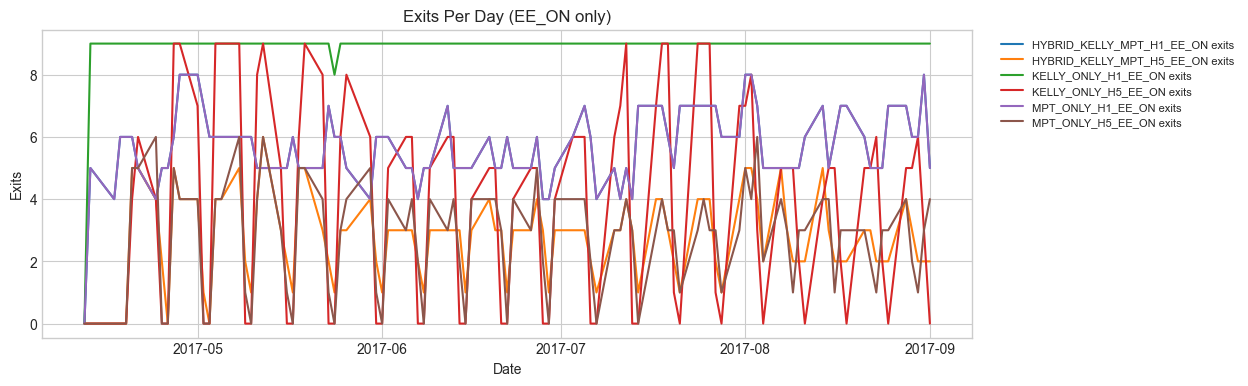

trades_made      exits     
                                  mean  sum  mean  sum
mode                                                  
HYBRID_KELLY_MPT_H1_EE_OFF        5.66  566  5.66  566
HYBRID_KELLY_MPT_H1_EE_ON         5.66  566  5.66  566
HYBRID_KELLY_MPT_H5_EE_OFF        2.72  272  2.72  272
HYBRID_KELLY_MPT_H5_EE_ON         2.72  272  2.72  272
KELLY_ONLY_H1_EE_OFF              8.90  890  8.90  890
KELLY_ONLY_H1_EE_ON               8.90  890  8.90  890
KELLY_ONLY_H5_EE_OFF              3.80  380  3.80  380
KELLY_ONLY_H5_EE_ON               3.80  380  3.80  380
MPT_ONLY_H1_EE_OFF                5.66  566  5.66  566
MPT_ONLY_H1_EE_ON                 5.66  566  5.66  566
MPT_ONLY_H5_EE_OFF                2.71  271  2.71  271
MPT_ONLY_H5_EE_ON                 2.71  271  2.71  271

In [67]:
trade_rows = []
for mode, df in dfs.items():
    if 'investments_made' in df.columns:
        inv = df['investments_made'].apply(_parse_maybe)
        trade_counts = inv.apply(lambda x: len(x) if isinstance(x, list) else 0)
    else:
        trade_counts = pd.Series(0, index=df.index)

    if 'exits_today' in df.columns:
        exits = df['exits_today'].apply(_parse_maybe)
        exit_counts = exits.apply(lambda x: len(x) if isinstance(x, list) else 0)
    else:
        exit_counts = pd.Series(0, index=df.index)

    trade_rows.append(pd.DataFrame({
        'date': df['date'],
        'mode': mode,
        'trades_made': trade_counts,
        'exits': exit_counts,
    }))

trades_df = pd.concat(trade_rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(12, 4))
for mode in trades_df['mode'].unique():
    df_mode = dfs.get(mode)
    if df_mode is not None and 'early_exit_enabled' in df_mode.columns:
        ee_on = bool(df_mode['early_exit_enabled'].iloc[0])
    else:
        ee_on = 'EE_ON' in str(mode)
    if ee_on:
        continue
    subset = trades_df[trades_df['mode'] == mode]
    ax.plot(subset['date'], subset['trades_made'], label=f'{mode} trades')
ax.set_title('Trades Per Day (EE_OFF only)')
ax.set_xlabel('Date')
ax.set_ylabel('Trades')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
for mode in trades_df['mode'].unique():
    df_mode = dfs.get(mode)
    if df_mode is not None and 'early_exit_enabled' in df_mode.columns:
        ee_on = bool(df_mode['early_exit_enabled'].iloc[0])
    else:
        ee_on = 'EE_ON' in str(mode)
    if not ee_on:
        continue
    subset = trades_df[trades_df['mode'] == mode]
    ax.plot(subset['date'], subset['exits'], label=f'{mode} exits')
ax.set_title('Exits Per Day (EE_ON only)')
ax.set_xlabel('Date')
ax.set_ylabel('Exits')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()

trades_summary = trades_df.groupby('mode')[['trades_made', 'exits']].agg(['mean', 'sum'])
trades_summary


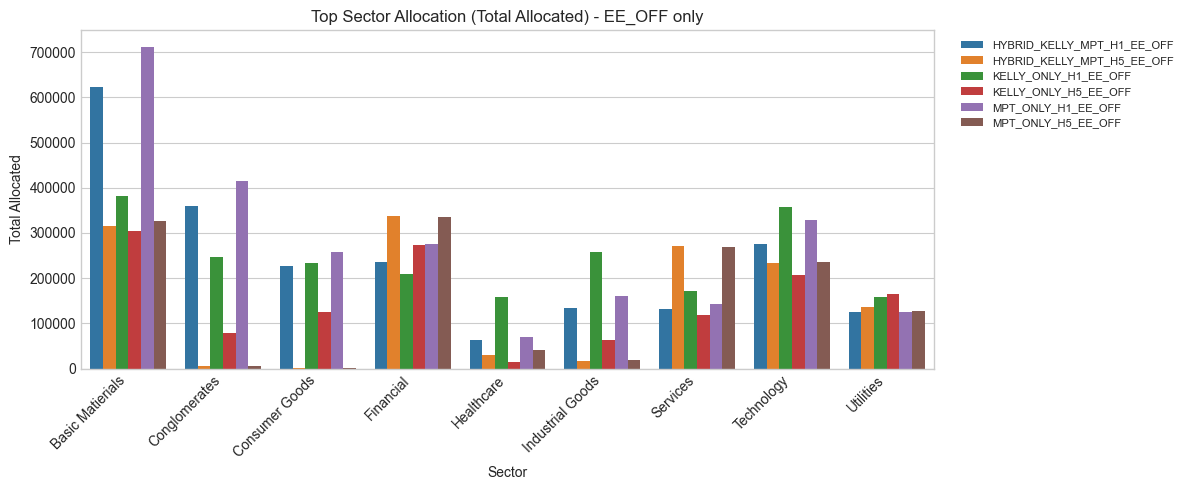

In [68]:
sector_rows = []
for mode, df in dfs.items():
    if 'investments_made' not in df.columns:
        continue
    if 'early_exit_enabled' in df.columns:
        ee_on = bool(df['early_exit_enabled'].iloc[0])
    else:
        ee_on = 'EE_ON' in str(mode)
    if ee_on:
        continue
    inv = df['investments_made'].apply(_parse_maybe)
    for day_list in inv:
        if not isinstance(day_list, list):
            continue
        for item in day_list:
            if not isinstance(item, dict):
                continue
            sector = item.get('sector', 'UNKNOWN')
            allocated = item.get('allocated_amount', item.get('invest', np.nan))
            sector_rows.append({'mode': mode, 'sector': sector, 'allocated': allocated})

sector_df = pd.DataFrame(sector_rows)
if not sector_df.empty:
    sector_summary = sector_df.groupby(['mode', 'sector'])['allocated'].sum().reset_index()
    top_sectors = sector_summary.groupby('sector')['allocated'].sum().nlargest(12).index
    plot_df = sector_summary[sector_summary['sector'].isin(top_sectors)]

    plt.figure(figsize=(12, 5))
    if _HAS_SEABORN:
        sns.barplot(data=plot_df, x='sector', y='allocated', hue='mode')
    else:
        for mode in plot_df['mode'].unique():
            subset = plot_df[plot_df['mode'] == mode]
            plt.bar(subset['sector'], subset['allocated'], alpha=0.6, label=mode)
    plt.title('Top Sector Allocation (Total Allocated) - EE_OFF only')
    plt.xlabel('Sector')
    plt.ylabel('Total Allocated')
    plt.xticks(rotation=45, ha='right')
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

    sector_pivot = sector_summary.pivot(index='sector', columns='mode', values='allocated').fillna(0)
    sector_pivot


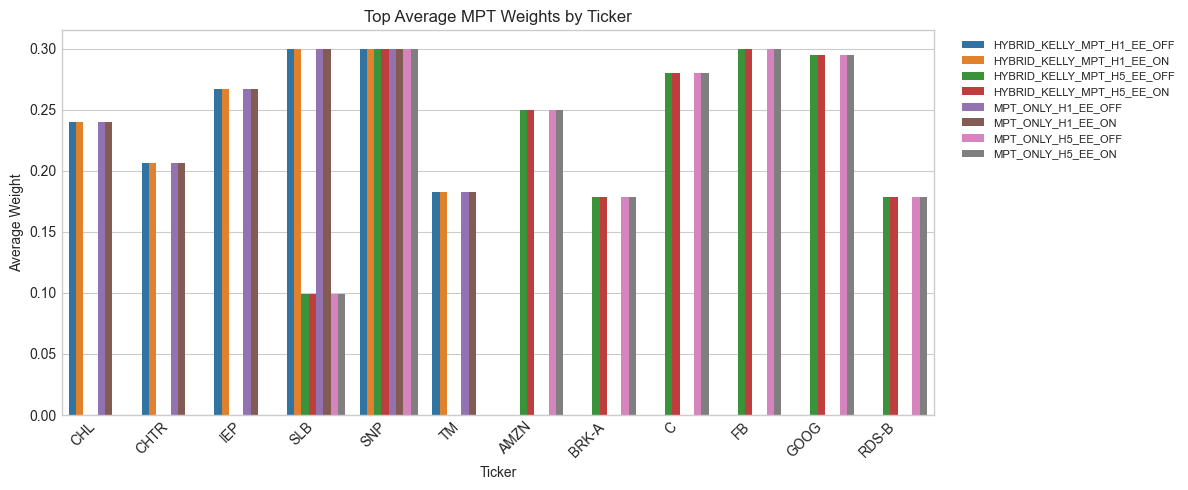

In [69]:
ticker_rows = []
for mode, df in dfs.items():
    if 'mpt_weights' not in df.columns:
        continue
    weights = df['mpt_weights'].apply(_parse_maybe)
    for weight_map in weights:
        if not isinstance(weight_map, dict):
            continue
        for ticker, w in weight_map.items():
            ticker_rows.append({'mode': mode, 'ticker': ticker, 'weight': float(w)})

ticker_df = pd.DataFrame(ticker_rows)
if not ticker_df.empty:
    ticker_summary = ticker_df.groupby(['mode', 'ticker'])['weight'].mean().reset_index()
    top_tickers = ticker_summary.groupby('ticker')['weight'].mean().nlargest(12).index
    plot_df = ticker_summary[ticker_summary['ticker'].isin(top_tickers)]

    plt.figure(figsize=(12, 5))
    if _HAS_SEABORN:
        sns.barplot(data=plot_df, x='ticker', y='weight', hue='mode')
    else:
        for mode in plot_df['mode'].unique():
            subset = plot_df[plot_df['mode'] == mode]
            plt.bar(subset['ticker'], subset['weight'], alpha=0.6, label=mode)
    plt.title('Top Average MPT Weights by Ticker')
    plt.xlabel('Ticker')
    plt.ylabel('Average Weight')
    plt.xticks(rotation=45, ha='right')
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

    ticker_pivot = ticker_summary.pivot(index='ticker', columns='mode', values='weight').fillna(0)
    ticker_pivot


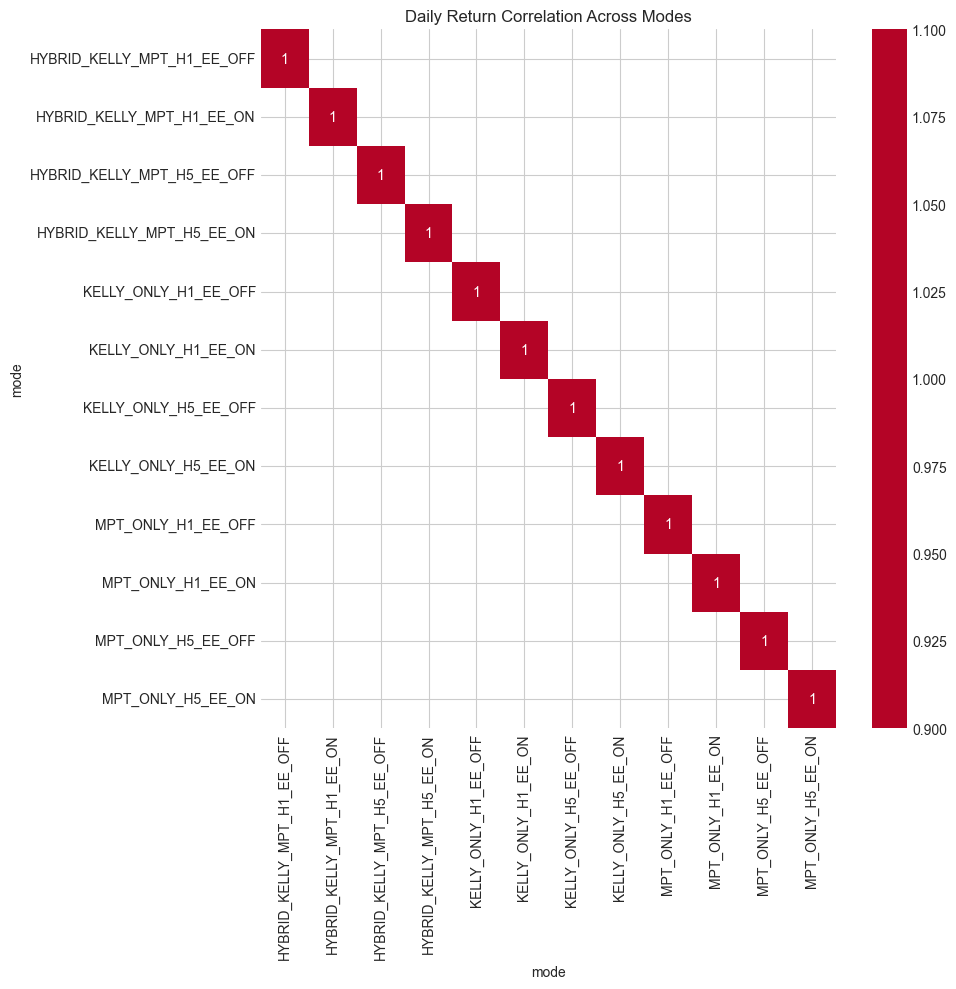

In [70]:
returns_pivot = returns_df.pivot(columns='mode', values='daily_return')
corr = returns_pivot.corr()

plt.figure(figsize=(10, 10))
if _HAS_SEABORN:
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
else:
    plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
    plt.yticks(range(len(corr.index)), corr.index)
    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')

plt.title('Daily Return Correlation Across Modes')
plt.tight_layout()
plt.show()


In [71]:
hyperparam_cols = [
    'H', 'initial_capital', 'initial_training_days', 'allow_overlap', 'seed', 'model_save_path',
    'min_sequence_length', 'max_sequence_length', 'kelly_fraction', 'sector_confidence_threshold',
    'retrain_interval', 'max_day_gap', 'mpt_window_days', 'mpt_lambda', 'mpt_ridge_eps',
    'mpt_max_weight', 'mpt_long_only', 'mpt_use_equal_fallback', 'mpt_only_budget_fraction',
    'max_total_utilization', 'max_new_daily_utilization', 'max_ticker_utilization',
    'max_sector_utilization', 'max_position_size', 'max_positions_per_ticker', 'min_trade_dollars',
    'kelly_trade_cap', 'drawdown_throttle_levels'
]

hyper_rows = []
for mode, df in dfs.items():
    row = {
        'mode': mode,
    }
    for col in hyperparam_cols:
        if col in df.columns:
            row[col] = df[col].iloc[0]
    hyper_rows.append(row)

hyper_df = pd.DataFrame(hyper_rows).set_index('mode')
hyper_df

# Summary table: trades, biggest winners/losers, average PnL, ROI, Sharpe
summary_rows = []

for mode, df in dfs.items():
    # Trade-level stats from exits_today
    exits_series = df['exits_today'].apply(_parse_maybe) if 'exits_today' in df.columns else pd.Series([], dtype=object)
    exit_trades = []
    for day_list in exits_series:
        if not isinstance(day_list, list):
            continue
        for item in day_list:
            if isinstance(item, dict):
                exit_trades.append(item)

    trades_df = pd.DataFrame(exit_trades)
    total_trades = len(trades_df)

    biggest_winner = np.nan
    biggest_loser = np.nan
    avg_pnl = np.nan
    if not trades_df.empty and 'pnl' in trades_df.columns:
        trades_df['pnl'] = pd.to_numeric(trades_df['pnl'], errors='coerce')
        biggest_winner = trades_df['pnl'].max()
        biggest_loser = trades_df['pnl'].min()
        avg_pnl = trades_df['pnl'].mean()

    # ROI + Sharpe from equity curve
    metrics = _metrics_from_df(df)

    summary_rows.append({
        'mode': mode,
        'total_trades': total_trades,
        'biggest_winner_pnl': biggest_winner,
        'biggest_loser_pnl': biggest_loser,
        'avg_trade_pnl': avg_pnl,
        'total_return': metrics.get('total_return'),
        'sharpe': metrics.get('sharpe'),
    })

summary_table = pd.DataFrame(summary_rows).set_index('mode')
summary_table


,total_trades,biggest_winner_pnl,biggest_loser_pnl,avg_trade_pnl,total_return,sharpe
mode,,,,,,
HYBRID_KELLY_MPT_H1_EE_OFF,566,238.873870,-197.035495,1.961728,0.011103,1.199480
HYBRID_KELLY_MPT_H1_EE_ON,566,238.873870,-197.035495,1.961728,0.011103,1.199480
HYBRID_KELLY_MPT_H5_EE_OFF,272,415.355445,-542.725574,13.545410,0.036844,2.535028
HYBRID_KELLY_MPT_H5_EE_ON,272,415.355445,-542.725574,13.545410,0.036844,2.535028
KELLY_ONLY_H1_EE_OFF,890,281.275642,-135.524448,0.978050,0.008705,1.079485
KELLY_ONLY_H1_EE_ON,890,281.275642,-135.524448,0.978050,0.008705,1.079485
KELLY_ONLY_H5_EE_OFF,380,227.362728,-319.455633,5.672999,0.021557,1.727564
KELLY_ONLY_H5_EE_ON,380,227.362728,-319.455633,5.672999,0.021557,1.727564
MPT_ONLY_H1_EE_OFF,566,275.602985,-207.394184,1.767048,0.010001,0.946339


In [72]:
# # Additional tables: top tickers/sectors winners/losers and summaries
# tables = {}

# for mode, df in dfs.items():
#     exits_series = df['exits_today'].apply(_parse_maybe) if 'exits_today' in df.columns else pd.Series([], dtype=object)
#     exit_trades = []
#     for day_list in exits_series:
#         if not isinstance(day_list, list):
#             continue
#         for item in day_list:
#             if isinstance(item, dict):
#                 exit_trades.append(item)

#     trades_df = pd.DataFrame(exit_trades)
#     if trades_df.empty:
#         continue

#     # Normalize fields
#     if 'pnl' in trades_df.columns:
#         trades_df['pnl'] = pd.to_numeric(trades_df['pnl'], errors='coerce')
#     if 'ticker' in trades_df.columns:
#         trades_df['ticker'] = trades_df['ticker'].astype(str)
#     if 'sector' in trades_df.columns:
#         trades_df['sector'] = trades_df['sector'].astype(str)

#     # Top/bottom trades overall
#     if 'pnl' in trades_df.columns:
#         tables[f'{mode} | Top 10 Trades (PnL)'] = trades_df.sort_values('pnl', ascending=False).head(10)
#         tables[f'{mode} | Bottom 10 Trades (PnL)'] = trades_df.sort_values('pnl', ascending=True).head(10)

#     # Ticker-level winners/losers
#     if {'ticker', 'pnl'}.issubset(trades_df.columns):
#         ticker_summary = trades_df.groupby('ticker')['pnl'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)
#         tables[f'{mode} | Top 10 Ticker Winners (Total PnL)'] = ticker_summary.head(10)
#         tables[f'{mode} | Top 10 Ticker Losers (Total PnL)'] = ticker_summary.tail(10).sort_values('sum')

#     # Sector-level winners/losers
#     if {'sector', 'pnl'}.issubset(trades_df.columns):
#         sector_summary = trades_df.groupby('sector')['pnl'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)
#         tables[f'{mode} | Top 10 Sector Winners (Total PnL)'] = sector_summary.head(10)
#         tables[f'{mode} | Top 10 Sector Losers (Total PnL)'] = sector_summary.tail(10).sort_values('sum')

# # Show all tables
# tables



# for name, table in tables.items():
#     print(f"\n=== {name} ===")
#     if isinstance(table, pd.DataFrame):
#         display(table)
#     else:
#         display(pd.DataFrame(table))


In [73]:
# ROI table (Total Return %)
roi_rows = []
for mode, df in dfs.items():
    metrics = _metrics_from_df(df)
    roi_rows.append({
        'mode': mode,
        'total_return': metrics.get('total_return'),
        'total_return_pct': (metrics.get('total_return') or np.nan) * 100.0,
        'CAGR': metrics.get('CAGR'),
    })

roi_table = pd.DataFrame(roi_rows).set_index('mode').sort_values('total_return', ascending=False)
roi_table


,total_return,total_return_pct,CAGR
mode,,,
MPT_ONLY_H5_EE_OFF,0.040386,4.038639,0.104919
MPT_ONLY_H5_EE_ON,0.040386,4.038639,0.104919
HYBRID_KELLY_MPT_H5_EE_OFF,0.036844,3.684352,0.095462
HYBRID_KELLY_MPT_H5_EE_ON,0.036844,3.684352,0.095462
KELLY_ONLY_H5_EE_OFF,0.021557,2.155739,0.055218
KELLY_ONLY_H5_EE_ON,0.021557,2.155739,0.055218
HYBRID_KELLY_MPT_H1_EE_OFF,0.011103,1.110338,0.028217
HYBRID_KELLY_MPT_H1_EE_ON,0.011103,1.110338,0.028217
MPT_ONLY_H1_EE_OFF,0.010001,1.000149,0.025396


In [74]:
# Combined table: ROI, Sharpe, avg trade size, avg trade PnL + hyperparameters
rows = []

for mode, df in dfs.items():
    metrics = _metrics_from_df(df)

    exits_series = df['exits_today'].apply(_parse_maybe) if 'exits_today' in df.columns else pd.Series([], dtype=object)
    exit_trades = []
    for day_list in exits_series:
        if not isinstance(day_list, list):
            continue
        for item in day_list:
            if isinstance(item, dict):
                exit_trades.append(item)

    trades_df = pd.DataFrame(exit_trades)
    avg_trade_size = np.nan
    avg_trade_pnl = np.nan
    if not trades_df.empty:
        if 'allocated_amount' in trades_df.columns:
            trades_df['allocated_amount'] = pd.to_numeric(trades_df['allocated_amount'], errors='coerce')
            avg_trade_size = trades_df['allocated_amount'].mean()
        if 'pnl' in trades_df.columns:
            trades_df['pnl'] = pd.to_numeric(trades_df['pnl'], errors='coerce')
            avg_trade_pnl = trades_df['pnl'].mean()

    row = {
        'mode': mode,
        'ROI': metrics.get('total_return'),
        'ROI_pct': (metrics.get('total_return') or np.nan) * 100.0,
        'Sharpe': metrics.get('sharpe'),
        'Avg_Trade_Size': avg_trade_size,
        'Avg_Trade_PnL': avg_trade_pnl,
    }

    # Attach hyperparameters
    if 'hyper_df' in globals():
        if mode in hyper_df.index:
            for col in hyper_df.columns:
                row[col] = hyper_df.loc[mode, col]
    else:
        # fallback: use first row from df if hyper_df not available
        for col in hyperparam_cols if 'hyperparam_cols' in globals() else []:
            if col in df.columns:
                row[col] = df[col].iloc[0]

    rows.append(row)

combined_table = pd.DataFrame(rows).set_index('mode')
combined_table


,ROI,ROI_pct,Sharpe,Avg_Trade_Size,Avg_Trade_PnL,H,initial_capital,initial_training_days,allow_overlap,seed,...,mpt_only_budget_fraction,max_total_utilization,max_new_daily_utilization,max_ticker_utilization,max_sector_utilization,max_position_size,max_positions_per_ticker,min_trade_dollars,kelly_trade_cap,drawdown_throttle_levels
mode,,,,,,,,,,,,,,,,,,,,,
HYBRID_KELLY_MPT_H1_EE_OFF,0.011103,1.110338,1.199480,3844.400728,1.961728,1,100000.0,1109,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"
HYBRID_KELLY_MPT_H1_EE_ON,0.011103,1.110338,1.199480,3844.400728,1.961728,1,100000.0,1109,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"
HYBRID_KELLY_MPT_H5_EE_OFF,0.036844,3.684352,2.535028,4965.362942,13.545410,5,100000.0,1109,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"
HYBRID_KELLY_MPT_H5_EE_ON,0.036844,3.684352,2.535028,4965.362942,13.545410,5,100000.0,1109,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"
KELLY_ONLY_H1_EE_OFF,0.008705,0.870465,1.079485,2444.150149,0.978050,1,100000.0,1109,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"
KELLY_ONLY_H1_EE_ON,0.008705,0.870465,1.079485,2444.150149,0.978050,1,100000.0,1109,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"
KELLY_ONLY_H5_EE_OFF,0.021557,2.155739,1.727564,3557.475994,5.672999,5,100000.0,1109,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"
KELLY_ONLY_H5_EE_ON,0.021557,2.155739,1.727564,3557.475994,5.672999,5,100000.0,1109,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"
MPT_ONLY_H1_EE_OFF,0.010001,1.000149,0.946339,4397.840363,1.767048,1,100000.0,1109,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"


## Binary with Meta Features

In [75]:
RESULTS_DIR_META = Path('../results/simulation/binary')
csv_paths = sorted(RESULTS_DIR_META.glob('*.csv'))
if not csv_paths:
    raise FileNotFoundError(f'No CSVs found in {RESULTS_DIR_META.resolve()}')

dfs = {}
for path in csv_paths:
    df = pd.read_csv(path)
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date')

    # Use filename stem as the primary label to avoid collisions
    mode = path.stem
    df['mode'] = mode
    dfs[mode] = df

list(dfs.keys())


['HYBRID_KELLY_MPT_H1_EE_OFF',
 'HYBRID_KELLY_MPT_H1_EE_ON',
 'HYBRID_KELLY_MPT_H5_EE_OFF',
 'HYBRID_KELLY_MPT_H5_EE_ON',
 'KELLY_ONLY_H1_EE_OFF',
 'KELLY_ONLY_H1_EE_ON',
 'KELLY_ONLY_H5_EE_OFF',
 'KELLY_ONLY_H5_EE_ON',
 'MPT_ONLY_H1_EE_OFF',
 'MPT_ONLY_H1_EE_ON',
 'MPT_ONLY_H5_EE_OFF',
 'MPT_ONLY_H5_EE_ON']

In [76]:
summary_rows = []
for mode, df in dfs.items():
    metrics = _metrics_from_df(df)
    metrics['mode'] = mode
    summary_rows.append(metrics)

summary_df = pd.DataFrame(summary_rows).set_index('mode').sort_values('total_return', ascending=False)
summary_df


,days,start_equity,end_equity,total_return,CAGR,volatility,sharpe,sortino,max_drawdown,win_rate,avg_win,avg_loss,profit_factor
mode,,,,,,,,,,,,,
HYBRID_KELLY_MPT_H5_EE_OFF,100,100000.0,121882.860851,0.218829,0.646552,0.082128,6.118325,12.924904,-0.027171,0.63,0.004091,-0.001945,4.417751
HYBRID_KELLY_MPT_H5_EE_ON,100,100000.0,121882.860851,0.218829,0.646552,0.082128,6.118325,12.924904,-0.027171,0.63,0.004091,-0.001945,4.417751
MPT_ONLY_H5_EE_OFF,100,100000.0,121719.711461,0.217197,0.641003,0.078949,6.318698,13.629480,-0.030334,0.57,0.004534,-0.002086,4.271736
MPT_ONLY_H5_EE_ON,100,100000.0,121719.711461,0.217197,0.641003,0.078949,6.318698,13.629480,-0.030334,0.57,0.004534,-0.002086,4.271736
KELLY_ONLY_H5_EE_OFF,100,100000.0,115502.749045,0.155027,0.437913,0.056595,6.449920,12.476264,-0.016519,0.37,0.005018,-0.002041,4.549073
KELLY_ONLY_H5_EE_ON,100,100000.0,115502.749045,0.155027,0.437913,0.056595,6.449920,12.476264,-0.016519,0.37,0.005018,-0.002041,4.549073
HYBRID_KELLY_MPT_H1_EE_OFF,100,100000.0,100748.192450,0.007482,0.018962,0.016895,1.120220,2.074883,-0.005350,0.50,0.000797,-0.000660,1.232292
HYBRID_KELLY_MPT_H1_EE_ON,100,100000.0,100748.192450,0.007482,0.018962,0.016895,1.120220,2.074883,-0.005350,0.50,0.000797,-0.000660,1.232292
KELLY_ONLY_H1_EE_OFF,100,100000.0,100673.012168,0.006730,0.017047,0.017650,0.966425,1.836838,-0.005478,0.46,0.000861,-0.000619,1.206258


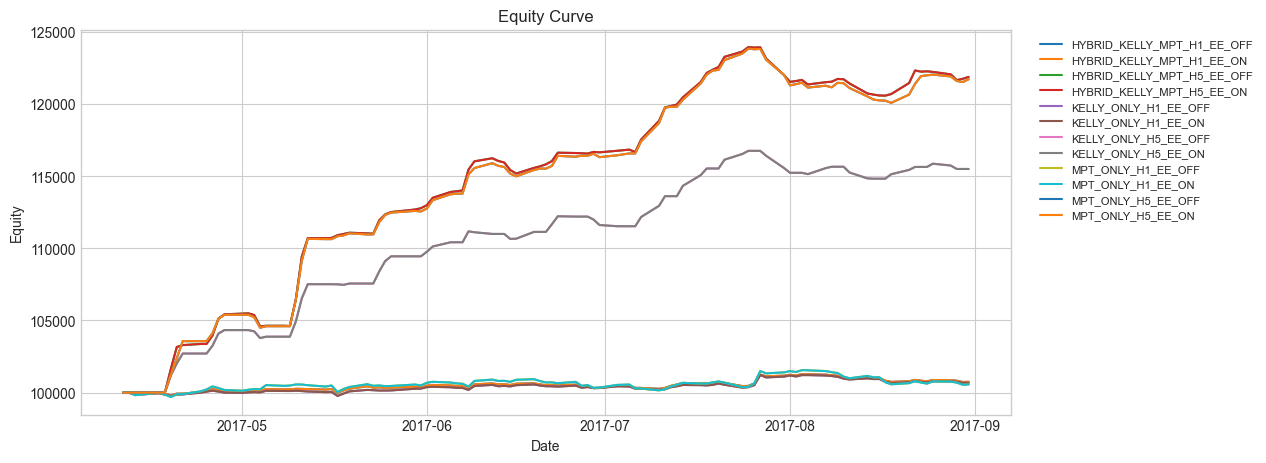

In [77]:
fig, ax = plt.subplots(figsize=(12, 5))
for mode, df in dfs.items():
    if 'equity_end' in df.columns:
        ax.plot(df['date'], df['equity_end'], label=mode)
ax.set_title('Equity Curve')
ax.set_xlabel('Date')
ax.set_ylabel('Equity')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()


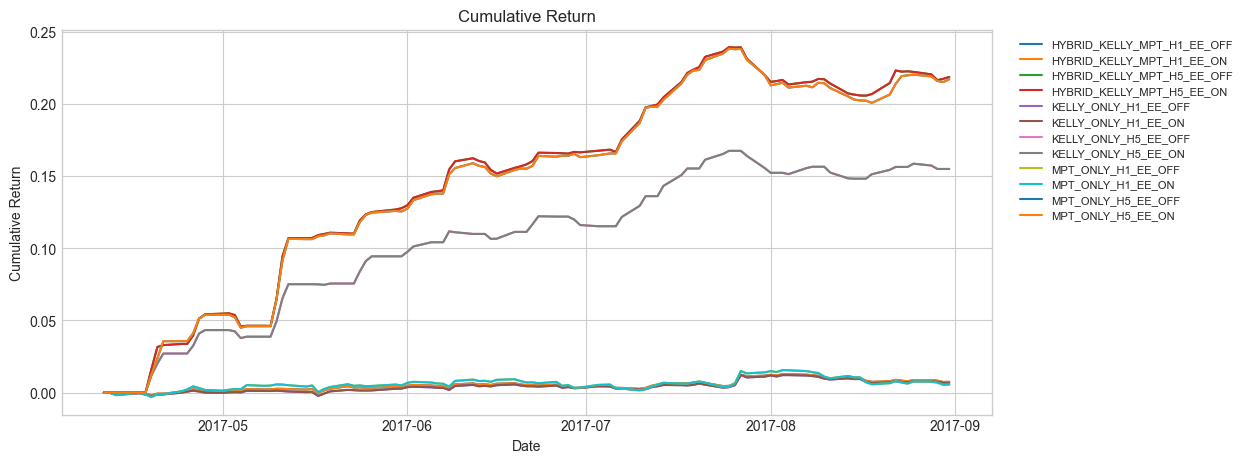

In [78]:
fig, ax = plt.subplots(figsize=(12, 5))
for mode, df in dfs.items():
    if 'equity_end' in df.columns and 'equity_start' in df.columns:
        base = df['equity_start'].iloc[0]
        ax.plot(df['date'], df['equity_end'] / base - 1.0, label=mode)
ax.set_title('Cumulative Return')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()


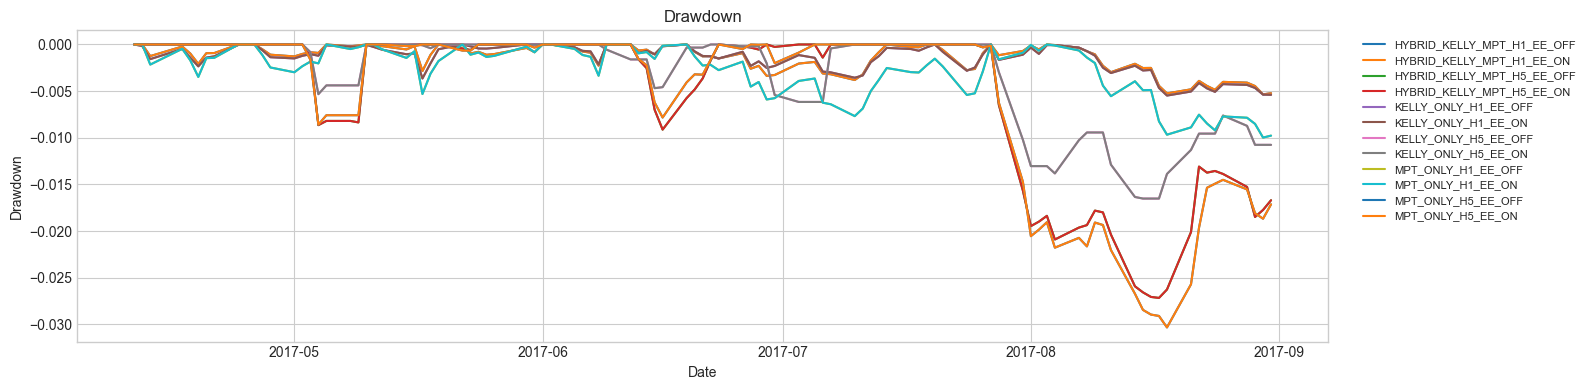

In [79]:
fig, ax = plt.subplots(figsize=(16, 4))
for mode, df in dfs.items():
    if 'equity_end' in df.columns:
        roll_max = df['equity_end'].cummax()
        drawdown = df['equity_end'] / roll_max - 1.0
        ax.plot(df['date'], drawdown, label=mode)
ax.set_title('Drawdown')
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


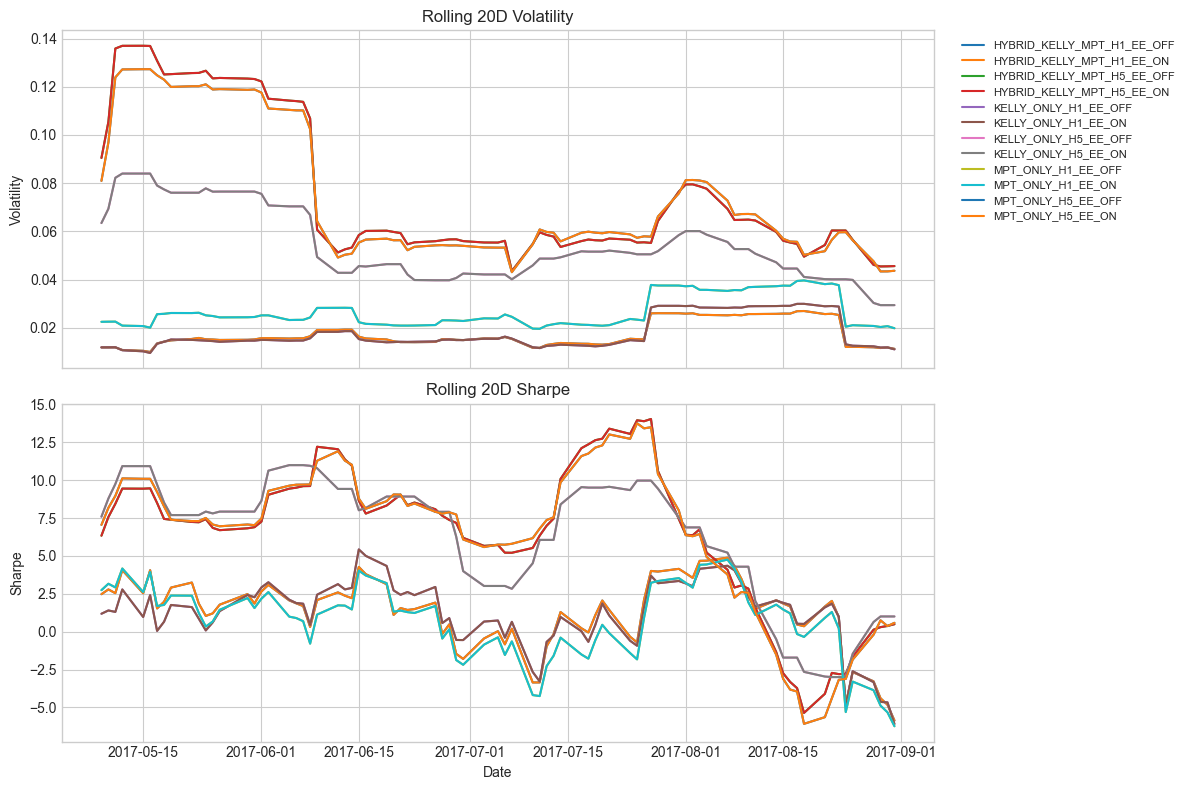

In [80]:
window = 20
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for mode, df in dfs.items():
    df = _ensure_returns(df)
    rets = df['daily_return'].astype(float).fillna(0.0)
    roll_vol = rets.rolling(window).std() * np.sqrt(252)
    roll_sharpe = rets.rolling(window).mean() / (rets.rolling(window).std() + 1e-12) * np.sqrt(252)
    axes[0].plot(df['date'], roll_vol, label=mode)
    axes[1].plot(df['date'], roll_sharpe, label=mode)

axes[0].set_title(f'Rolling {window}D Volatility')
axes[0].set_ylabel('Volatility')
axes[1].set_title(f'Rolling {window}D Sharpe')
axes[1].set_ylabel('Sharpe')
axes[1].set_xlabel('Date')
axes[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


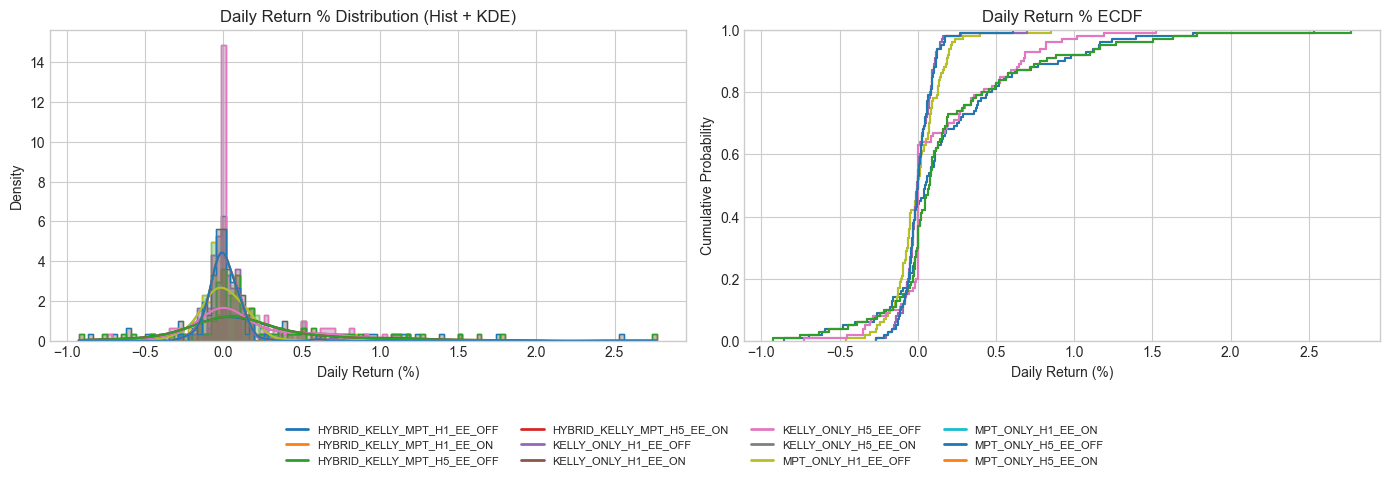

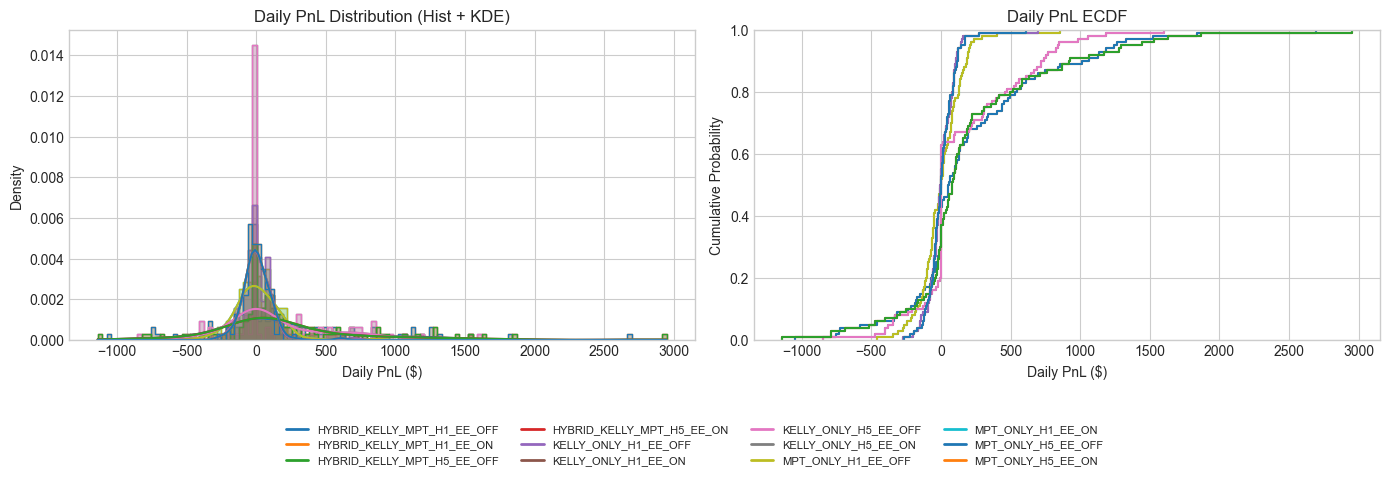

,max_abs_diff,mean_abs_diff,csv_nonnull,calc_nonnull
mode,,,,
HYBRID_KELLY_MPT_H1_EE_OFF,5.275728e-16,1.610218e-16,100,100
HYBRID_KELLY_MPT_H1_EE_ON,5.275728e-16,1.610218e-16,100,100
HYBRID_KELLY_MPT_H5_EE_OFF,4.169842e-16,1.120881e-16,100,100
HYBRID_KELLY_MPT_H5_EE_ON,4.169842e-16,1.120881e-16,100,100
KELLY_ONLY_H1_EE_OFF,4.214294e-16,1.367381e-16,100,100
KELLY_ONLY_H1_EE_ON,4.214294e-16,1.367381e-16,100,100
KELLY_ONLY_H5_EE_OFF,5.074066e-16,9.323000e-17,100,100
KELLY_ONLY_H5_EE_ON,5.074066e-16,9.323000e-17,100,100
MPT_ONLY_H1_EE_OFF,5.373306e-16,1.645391e-16,100,100


In [81]:
all_returns = []
pnl_rows = []
diag_rows = []
for mode, df in dfs.items():
    df = df.copy()
    csv_returns = df['daily_return'].astype(float) if 'daily_return' in df.columns else pd.Series(np.nan, index=df.index)
    calc_returns = _calc_daily_return(df).astype(float)

    diff = (csv_returns - calc_returns).abs()
    diag_rows.append({
        'mode': mode,
        'max_abs_diff': diff.max(),
        'mean_abs_diff': diff.mean(),
        'csv_nonnull': csv_returns.notna().sum(),
        'calc_nonnull': calc_returns.notna().sum(),
    })

    all_returns.append(pd.DataFrame({'mode': mode, 'daily_return': calc_returns}))
    if 'daily_pnl_realized' in df.columns:
        pnl_rows.append(pd.DataFrame({'mode': mode, 'daily_pnl': df['daily_pnl_realized'].astype(float)}))

returns_df = pd.concat(all_returns, ignore_index=True)
returns_df = returns_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['daily_return'])
returns_df['daily_return_pct'] = returns_df['daily_return'] * 100.0

pnl_df = pd.concat(pnl_rows, ignore_index=True) if pnl_rows else pd.DataFrame(columns=['mode', 'daily_pnl'])
pnl_df = pnl_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['daily_pnl'])

# Build a color map that covers all modes present
mode_order = sorted(returns_df['mode'].unique())
if _HAS_SEABORN:
    palette = sns.color_palette('tab10', n_colors=max(len(mode_order), 1))
else:
    palette = plt.cm.tab10.colors if len(mode_order) <= 10 else plt.cm.tab20.colors
mode_color_map = {mode: palette[i % len(palette)] for i, mode in enumerate(mode_order)}

# -------------------- RETURNS FIGURE --------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Returns: histogram + KDE
if _HAS_SEABORN:
    sns.histplot(data=returns_df, x='daily_return_pct', hue='mode', element='step', stat='density',
                 common_norm=False, kde=True, palette=mode_color_map, ax=axes[0], legend=False)
else:
    for mode in returns_df['mode'].unique():
        subset = returns_df[returns_df['mode'] == mode]['daily_return_pct']
        axes[0].hist(subset, bins=30, alpha=0.35, label=mode, density=True, color=mode_color_map.get(mode))
axes[0].set_title('Daily Return % Distribution (Hist + KDE)')
axes[0].set_xlabel('Daily Return (%)')
axes[0].set_ylabel('Density')

# Returns: ECDF
if _HAS_SEABORN:
    sns.ecdfplot(data=returns_df, x='daily_return_pct', hue='mode', palette=mode_color_map, ax=axes[1], legend=False)
else:
    for mode in returns_df['mode'].unique():
        subset = np.sort(returns_df[returns_df['mode'] == mode]['daily_return_pct'].values)
        y = np.arange(1, len(subset) + 1) / len(subset)
        axes[1].plot(subset, y, label=mode, color=mode_color_map.get(mode))
axes[1].set_title('Daily Return % ECDF')
axes[1].set_xlabel('Daily Return (%)')
axes[1].set_ylabel('Cumulative Probability')

# Shared legend below the returns plots
handles = [plt.Line2D([0], [0], color=mode_color_map[m], lw=2) for m in mode_order]
fig.legend(handles, mode_order, loc='upper center', bbox_to_anchor=(0.5, -0.05),
           ncol=min(len(mode_order), 4), frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# -------------------- PNL FIGURE --------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# PnL: histogram + KDE
if not pnl_df.empty:
    if _HAS_SEABORN:
        sns.histplot(data=pnl_df, x='daily_pnl', hue='mode', element='step', stat='density',
                     common_norm=False, kde=True, palette=mode_color_map, ax=axes[0], legend=False)
    else:
        for mode in pnl_df['mode'].unique():
            subset = pnl_df[pnl_df['mode'] == mode]['daily_pnl']
            axes[0].hist(subset, bins=30, alpha=0.35, label=mode, density=True, color=mode_color_map.get(mode))
    axes[0].set_title('Daily PnL Distribution (Hist + KDE)')
    axes[0].set_xlabel('Daily PnL ($)')
    axes[0].set_ylabel('Density')
else:
    axes[0].text(0.5, 0.5, 'No daily_pnl_realized column found', ha='center', va='center')
    axes[0].set_axis_off()

# PnL: ECDF
if not pnl_df.empty:
    if _HAS_SEABORN:
        sns.ecdfplot(data=pnl_df, x='daily_pnl', hue='mode', palette=mode_color_map, ax=axes[1], legend=False)
    else:
        for mode in pnl_df['mode'].unique():
            subset = np.sort(pnl_df[pnl_df['mode'] == mode]['daily_pnl'].values)
            y = np.arange(1, len(subset) + 1) / len(subset)
            axes[1].plot(subset, y, label=mode, color=mode_color_map.get(mode))
    axes[1].set_title('Daily PnL ECDF')
    axes[1].set_xlabel('Daily PnL ($)')
    axes[1].set_ylabel('Cumulative Probability')
else:
    axes[1].text(0.5, 0.5, 'No daily_pnl_realized column found', ha='center', va='center')
    axes[1].set_axis_off()

# Shared legend below the pnl plots
if not pnl_df.empty:
    fig.legend(handles, mode_order, loc='upper center', bbox_to_anchor=(0.5, -0.05),
               ncol=min(len(mode_order), 4), frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

pd.DataFrame(diag_rows).set_index('mode')


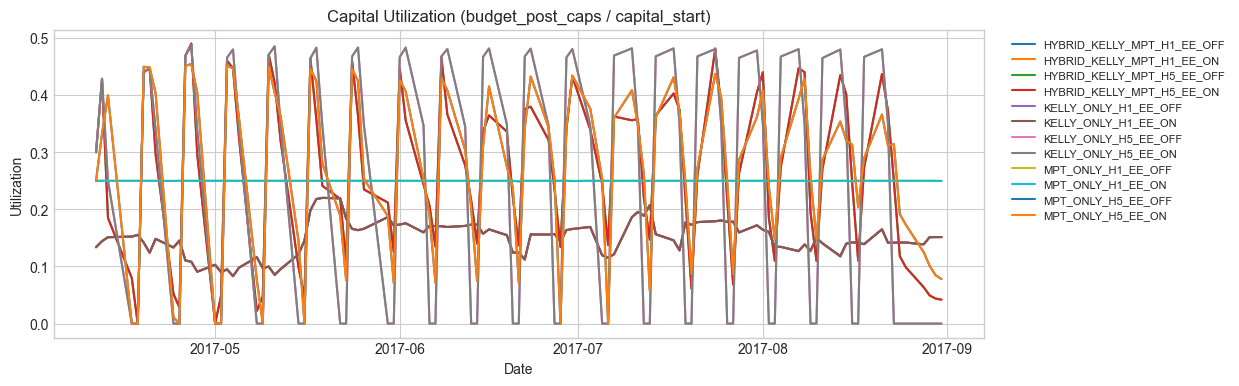

In [82]:
fig, ax = plt.subplots(figsize=(12, 4))
for mode, df in dfs.items():
    if {'budget_post_caps', 'capital_start'}.issubset(df.columns):
        utilization = df['budget_post_caps'] / df['capital_start']
        ax.plot(df['date'], utilization, label=mode)
ax.set_title('Capital Utilization (budget_post_caps / capital_start)')
ax.set_xlabel('Date')
ax.set_ylabel('Utilization')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()


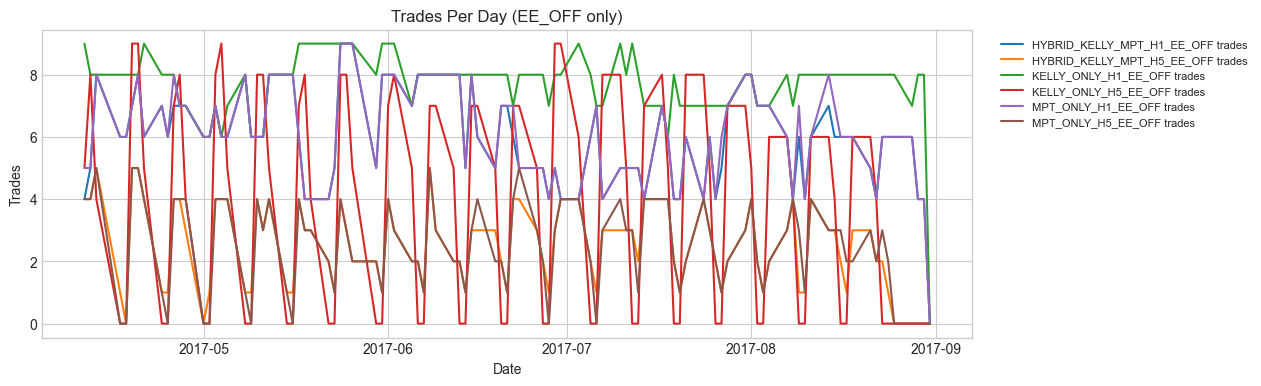

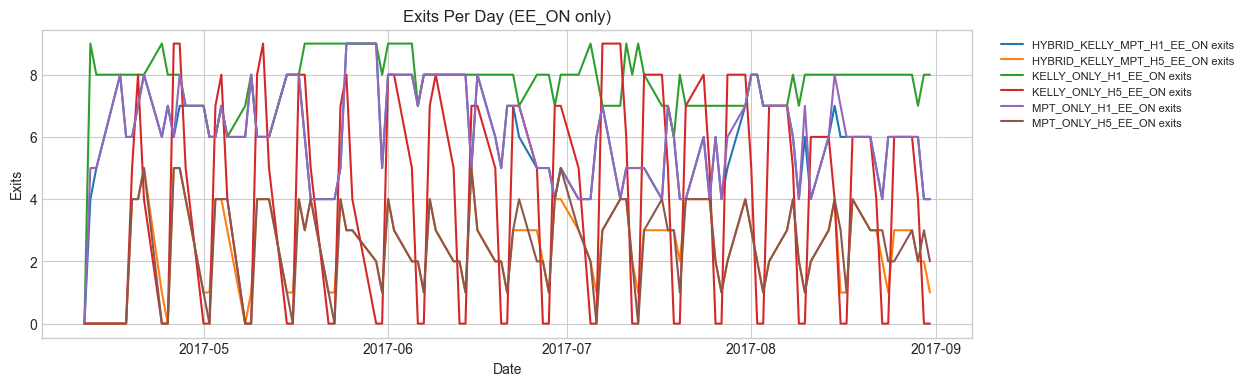

trades_made      exits     
                                  mean  sum  mean  sum
mode                                                  
HYBRID_KELLY_MPT_H1_EE_OFF        6.04  604  6.04  604
HYBRID_KELLY_MPT_H1_EE_ON         6.04  604  6.04  604
HYBRID_KELLY_MPT_H5_EE_OFF        2.47  247  2.47  247
HYBRID_KELLY_MPT_H5_EE_ON         2.47  247  2.47  247
KELLY_ONLY_H1_EE_OFF              7.71  771  7.71  771
KELLY_ONLY_H1_EE_ON               7.71  771  7.71  771
KELLY_ONLY_H5_EE_OFF              3.72  372  3.72  372
KELLY_ONLY_H5_EE_ON               3.72  372  3.72  372
MPT_ONLY_H1_EE_OFF                6.11  611  6.11  611
MPT_ONLY_H1_EE_ON                 6.11  611  6.11  611
MPT_ONLY_H5_EE_OFF                2.47  247  2.47  247
MPT_ONLY_H5_EE_ON                 2.47  247  2.47  247

In [83]:
trade_rows = []
for mode, df in dfs.items():
    if 'investments_made' in df.columns:
        inv = df['investments_made'].apply(_parse_maybe)
        trade_counts = inv.apply(lambda x: len(x) if isinstance(x, list) else 0)
    else:
        trade_counts = pd.Series(0, index=df.index)

    if 'exits_today' in df.columns:
        exits = df['exits_today'].apply(_parse_maybe)
        exit_counts = exits.apply(lambda x: len(x) if isinstance(x, list) else 0)
    else:
        exit_counts = pd.Series(0, index=df.index)

    trade_rows.append(pd.DataFrame({
        'date': df['date'],
        'mode': mode,
        'trades_made': trade_counts,
        'exits': exit_counts,
    }))

trades_df = pd.concat(trade_rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(12, 4))
for mode in trades_df['mode'].unique():
    df_mode = dfs.get(mode)
    if df_mode is not None and 'early_exit_enabled' in df_mode.columns:
        ee_on = bool(df_mode['early_exit_enabled'].iloc[0])
    else:
        ee_on = 'EE_ON' in str(mode)
    if ee_on:
        continue
    subset = trades_df[trades_df['mode'] == mode]
    ax.plot(subset['date'], subset['trades_made'], label=f'{mode} trades')
ax.set_title('Trades Per Day (EE_OFF only)')
ax.set_xlabel('Date')
ax.set_ylabel('Trades')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
for mode in trades_df['mode'].unique():
    df_mode = dfs.get(mode)
    if df_mode is not None and 'early_exit_enabled' in df_mode.columns:
        ee_on = bool(df_mode['early_exit_enabled'].iloc[0])
    else:
        ee_on = 'EE_ON' in str(mode)
    if not ee_on:
        continue
    subset = trades_df[trades_df['mode'] == mode]
    ax.plot(subset['date'], subset['exits'], label=f'{mode} exits')
ax.set_title('Exits Per Day (EE_ON only)')
ax.set_xlabel('Date')
ax.set_ylabel('Exits')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()

trades_summary = trades_df.groupby('mode')[['trades_made', 'exits']].agg(['mean', 'sum'])
trades_summary


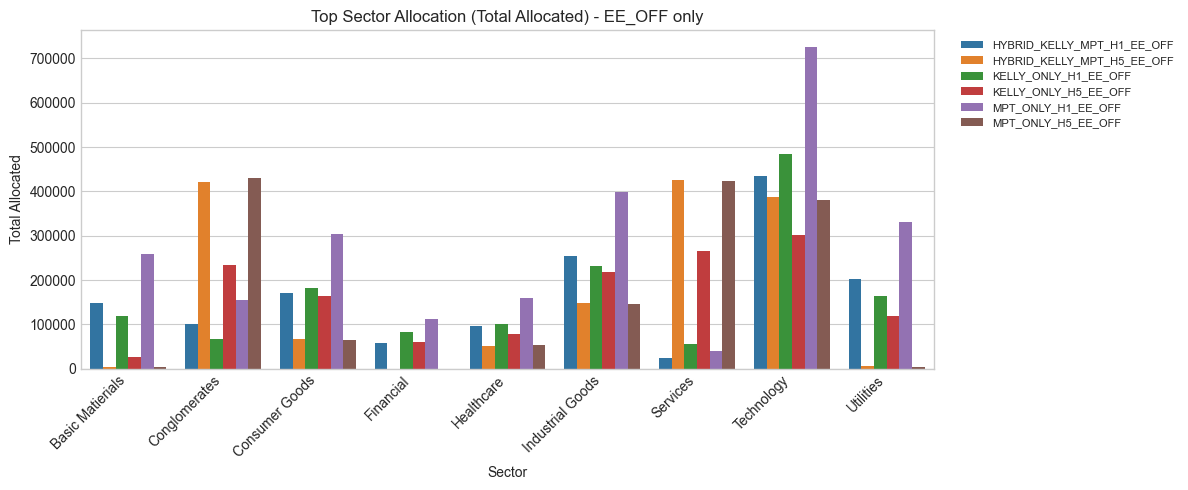

In [84]:
sector_rows = []
for mode, df in dfs.items():
    if 'investments_made' not in df.columns:
        continue
    if 'early_exit_enabled' in df.columns:
        ee_on = bool(df['early_exit_enabled'].iloc[0])
    else:
        ee_on = 'EE_ON' in str(mode)
    if ee_on:
        continue
    inv = df['investments_made'].apply(_parse_maybe)
    for day_list in inv:
        if not isinstance(day_list, list):
            continue
        for item in day_list:
            if not isinstance(item, dict):
                continue
            sector = item.get('sector', 'UNKNOWN')
            allocated = item.get('allocated_amount', item.get('invest', np.nan))
            sector_rows.append({'mode': mode, 'sector': sector, 'allocated': allocated})

sector_df = pd.DataFrame(sector_rows)
if not sector_df.empty:
    sector_summary = sector_df.groupby(['mode', 'sector'])['allocated'].sum().reset_index()
    top_sectors = sector_summary.groupby('sector')['allocated'].sum().nlargest(12).index
    plot_df = sector_summary[sector_summary['sector'].isin(top_sectors)]

    plt.figure(figsize=(12, 5))
    if _HAS_SEABORN:
        sns.barplot(data=plot_df, x='sector', y='allocated', hue='mode')
    else:
        for mode in plot_df['mode'].unique():
            subset = plot_df[plot_df['mode'] == mode]
            plt.bar(subset['sector'], subset['allocated'], alpha=0.6, label=mode)
    plt.title('Top Sector Allocation (Total Allocated) - EE_OFF only')
    plt.xlabel('Sector')
    plt.ylabel('Total Allocated')
    plt.xticks(rotation=45, ha='right')
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

    sector_pivot = sector_summary.pivot(index='sector', columns='mode', values='allocated').fillna(0)
    sector_pivot


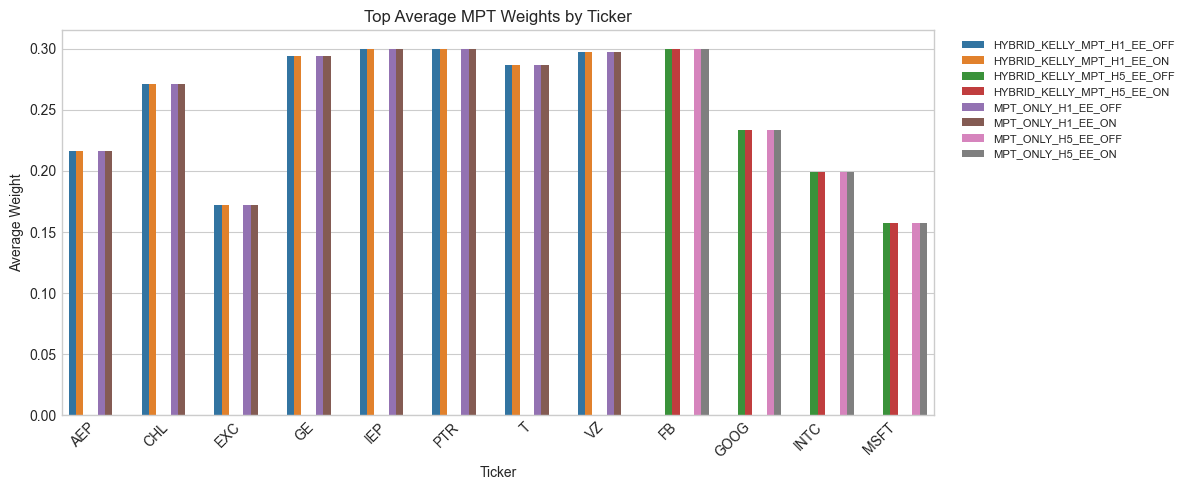

In [85]:
ticker_rows = []
for mode, df in dfs.items():
    if 'mpt_weights' not in df.columns:
        continue
    weights = df['mpt_weights'].apply(_parse_maybe)
    for weight_map in weights:
        if not isinstance(weight_map, dict):
            continue
        for ticker, w in weight_map.items():
            ticker_rows.append({'mode': mode, 'ticker': ticker, 'weight': float(w)})

ticker_df = pd.DataFrame(ticker_rows)
if not ticker_df.empty:
    ticker_summary = ticker_df.groupby(['mode', 'ticker'])['weight'].mean().reset_index()
    top_tickers = ticker_summary.groupby('ticker')['weight'].mean().nlargest(12).index
    plot_df = ticker_summary[ticker_summary['ticker'].isin(top_tickers)]

    plt.figure(figsize=(12, 5))
    if _HAS_SEABORN:
        sns.barplot(data=plot_df, x='ticker', y='weight', hue='mode')
    else:
        for mode in plot_df['mode'].unique():
            subset = plot_df[plot_df['mode'] == mode]
            plt.bar(subset['ticker'], subset['weight'], alpha=0.6, label=mode)
    plt.title('Top Average MPT Weights by Ticker')
    plt.xlabel('Ticker')
    plt.ylabel('Average Weight')
    plt.xticks(rotation=45, ha='right')
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

    ticker_pivot = ticker_summary.pivot(index='ticker', columns='mode', values='weight').fillna(0)
    ticker_pivot


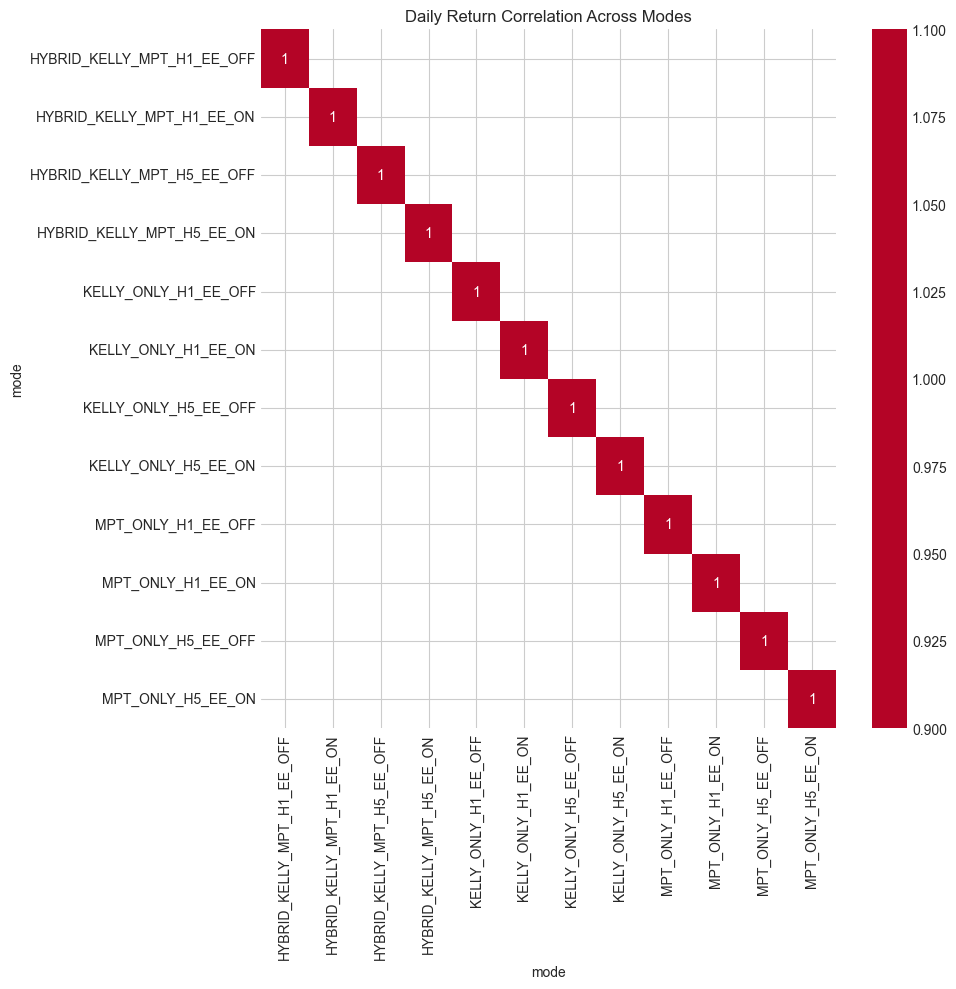

In [86]:
returns_pivot = returns_df.pivot(columns='mode', values='daily_return')
corr = returns_pivot.corr()

plt.figure(figsize=(10, 10))
if _HAS_SEABORN:
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
else:
    plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
    plt.yticks(range(len(corr.index)), corr.index)
    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')

plt.title('Daily Return Correlation Across Modes')
plt.tight_layout()
plt.show()


In [87]:
hyperparam_cols = [
    'H', 'initial_capital', 'initial_training_days', 'allow_overlap', 'seed', 'model_save_path',
    'min_sequence_length', 'max_sequence_length', 'kelly_fraction', 'sector_confidence_threshold',
    'retrain_interval', 'max_day_gap', 'mpt_window_days', 'mpt_lambda', 'mpt_ridge_eps',
    'mpt_max_weight', 'mpt_long_only', 'mpt_use_equal_fallback', 'mpt_only_budget_fraction',
    'max_total_utilization', 'max_new_daily_utilization', 'max_ticker_utilization',
    'max_sector_utilization', 'max_position_size', 'max_positions_per_ticker', 'min_trade_dollars',
    'kelly_trade_cap', 'drawdown_throttle_levels'
]

hyper_rows = []
for mode, df in dfs.items():
    row = {
        'mode': mode,
    }
    for col in hyperparam_cols:
        if col in df.columns:
            row[col] = df[col].iloc[0]
    hyper_rows.append(row)

hyper_df = pd.DataFrame(hyper_rows).set_index('mode')
hyper_df




,H,initial_capital,initial_training_days,allow_overlap,seed,model_save_path,min_sequence_length,max_sequence_length,kelly_fraction,sector_confidence_threshold,...,mpt_only_budget_fraction,max_total_utilization,max_new_daily_utilization,max_ticker_utilization,max_sector_utilization,max_position_size,max_positions_per_ticker,min_trade_dollars,kelly_trade_cap,drawdown_throttle_levels
mode,,,,,,,,,,,,,,,,,,,,,
HYBRID_KELLY_MPT_H1_EE_OFF,1,100000.0,853,True,42,/mnt/primary/simulation/trained_models_meta,12,12,0.15,0.3,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"
HYBRID_KELLY_MPT_H1_EE_ON,1,100000.0,853,True,42,/mnt/primary/simulation/trained_models_meta,12,12,0.15,0.3,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"
HYBRID_KELLY_MPT_H5_EE_OFF,5,100000.0,853,True,42,/mnt/primary/simulation/trained_models_meta,12,12,0.15,0.3,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"
HYBRID_KELLY_MPT_H5_EE_ON,5,100000.0,853,True,42,/mnt/primary/simulation/trained_models_meta,12,12,0.15,0.3,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"
KELLY_ONLY_H1_EE_OFF,1,100000.0,853,True,42,/mnt/primary/simulation/trained_models_meta,12,12,0.15,0.3,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"
KELLY_ONLY_H1_EE_ON,1,100000.0,853,True,42,/mnt/primary/simulation/trained_models_meta,12,12,0.15,0.3,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"
KELLY_ONLY_H5_EE_OFF,5,100000.0,853,True,42,/mnt/primary/simulation/trained_models_meta,12,12,0.15,0.3,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"
KELLY_ONLY_H5_EE_ON,5,100000.0,853,True,42,/mnt/primary/simulation/trained_models_meta,12,12,0.15,0.3,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"
MPT_ONLY_H1_EE_OFF,1,100000.0,853,True,42,/mnt/primary/simulation/trained_models_meta,12,12,0.15,0.3,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"


In [88]:
# Summary table: trades, biggest winners/losers, average PnL, ROI, Sharpe
summary_rows = []

for mode, df in dfs.items():
    # Trade-level stats from exits_today
    exits_series = df['exits_today'].apply(_parse_maybe) if 'exits_today' in df.columns else pd.Series([], dtype=object)
    exit_trades = []
    for day_list in exits_series:
        if not isinstance(day_list, list):
            continue
        for item in day_list:
            if isinstance(item, dict):
                exit_trades.append(item)

    trades_df = pd.DataFrame(exit_trades)
    total_trades = len(trades_df)

    biggest_winner = np.nan
    biggest_loser = np.nan
    avg_pnl = np.nan
    if not trades_df.empty and 'pnl' in trades_df.columns:
        trades_df['pnl'] = pd.to_numeric(trades_df['pnl'], errors='coerce')
        biggest_winner = trades_df['pnl'].max()
        biggest_loser = trades_df['pnl'].min()
        avg_pnl = trades_df['pnl'].mean()

    # ROI + Sharpe from equity curve
    metrics = _metrics_from_df(df)

    summary_rows.append({
        'mode': mode,
        'total_trades': total_trades,
        'biggest_winner_pnl': biggest_winner,
        'biggest_loser_pnl': biggest_loser,
        'avg_trade_pnl': avg_pnl,
        'total_return': metrics.get('total_return'),
        'sharpe': metrics.get('sharpe'),
    })

summary_table = pd.DataFrame(summary_rows).set_index('mode')
summary_table

,total_trades,biggest_winner_pnl,biggest_loser_pnl,avg_trade_pnl,total_return,sharpe
mode,,,,,,
HYBRID_KELLY_MPT_H1_EE_OFF,604,412.729222,-152.850081,1.238729,0.007482,1.120220
HYBRID_KELLY_MPT_H1_EE_ON,604,412.729222,-152.850081,1.238729,0.007482,1.120220
HYBRID_KELLY_MPT_H5_EE_OFF,247,2649.435581,-966.482425,88.594578,0.218829,6.118325
HYBRID_KELLY_MPT_H5_EE_ON,247,2649.435581,-966.482425,88.594578,0.218829,6.118325
KELLY_ONLY_H1_EE_OFF,771,508.561170,-161.333506,0.872908,0.006730,0.966425
KELLY_ONLY_H1_EE_ON,771,508.561170,-161.333506,0.872908,0.006730,0.966425
KELLY_ONLY_H5_EE_OFF,372,1424.585369,-520.473608,41.674057,0.155027,6.449920
KELLY_ONLY_H5_EE_ON,372,1424.585369,-520.473608,41.674057,0.155027,6.449920
MPT_ONLY_H1_EE_OFF,611,579.685830,-220.881888,0.923916,0.005645,0.556365


In [89]:
# ROI table (Total Return %)
roi_rows = []
for mode, df in dfs.items():
    metrics = _metrics_from_df(df)
    roi_rows.append({
        'mode': mode,
        'total_return': metrics.get('total_return'),
        'total_return_pct': (metrics.get('total_return') or np.nan) * 100.0,
        'CAGR': metrics.get('CAGR'),
    })

roi_table = pd.DataFrame(roi_rows).set_index('mode').sort_values('total_return', ascending=False)
roi_table


,total_return,total_return_pct,CAGR
mode,,,
HYBRID_KELLY_MPT_H5_EE_OFF,0.218829,21.882861,0.646552
HYBRID_KELLY_MPT_H5_EE_ON,0.218829,21.882861,0.646552
MPT_ONLY_H5_EE_OFF,0.217197,21.719711,0.641003
MPT_ONLY_H5_EE_ON,0.217197,21.719711,0.641003
KELLY_ONLY_H5_EE_OFF,0.155027,15.502749,0.437913
KELLY_ONLY_H5_EE_ON,0.155027,15.502749,0.437913
HYBRID_KELLY_MPT_H1_EE_OFF,0.007482,0.748192,0.018962
HYBRID_KELLY_MPT_H1_EE_ON,0.007482,0.748192,0.018962
KELLY_ONLY_H1_EE_OFF,0.006730,0.673012,0.017047


In [90]:
# Combined table: ROI, Sharpe, avg trade size, avg trade PnL + hyperparameters
rows = []

for mode, df in dfs.items():
    metrics = _metrics_from_df(df)

    exits_series = df['exits_today'].apply(_parse_maybe) if 'exits_today' in df.columns else pd.Series([], dtype=object)
    exit_trades = []
    for day_list in exits_series:
        if not isinstance(day_list, list):
            continue
        for item in day_list:
            if isinstance(item, dict):
                exit_trades.append(item)

    trades_df = pd.DataFrame(exit_trades)
    avg_trade_size = np.nan
    avg_trade_pnl = np.nan
    if not trades_df.empty:
        if 'allocated_amount' in trades_df.columns:
            trades_df['allocated_amount'] = pd.to_numeric(trades_df['allocated_amount'], errors='coerce')
            avg_trade_size = trades_df['allocated_amount'].mean()
        if 'pnl' in trades_df.columns:
            trades_df['pnl'] = pd.to_numeric(trades_df['pnl'], errors='coerce')
            avg_trade_pnl = trades_df['pnl'].mean()

    row = {
        'mode': mode,
        'ROI': metrics.get('total_return'),
        'ROI_pct': (metrics.get('total_return') or np.nan) * 100.0,
        'Sharpe': metrics.get('sharpe'),
        'Avg_Trade_Size': avg_trade_size,
        'Avg_Trade_PnL': avg_trade_pnl,
    }

    # Attach hyperparameters
    if 'hyper_df' in globals():
        if mode in hyper_df.index:
            for col in hyper_df.columns:
                row[col] = hyper_df.loc[mode, col]
    else:
        # fallback: use first row from df if hyper_df not available
        for col in hyperparam_cols if 'hyperparam_cols' in globals() else []:
            if col in df.columns:
                row[col] = df[col].iloc[0]

    rows.append(row)

combined_table = pd.DataFrame(rows).set_index('mode')
combined_table


,ROI,ROI_pct,Sharpe,Avg_Trade_Size,Avg_Trade_PnL,H,initial_capital,initial_training_days,allow_overlap,seed,...,mpt_only_budget_fraction,max_total_utilization,max_new_daily_utilization,max_ticker_utilization,max_sector_utilization,max_position_size,max_positions_per_ticker,min_trade_dollars,kelly_trade_cap,drawdown_throttle_levels
mode,,,,,,,,,,,,,,,,,,,,,
HYBRID_KELLY_MPT_H1_EE_OFF,0.007482,0.748192,1.120220,2460.913446,1.238729,1,100000.0,853,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"
HYBRID_KELLY_MPT_H1_EE_ON,0.007482,0.748192,1.120220,2460.913446,1.238729,1,100000.0,853,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"
HYBRID_KELLY_MPT_H5_EE_OFF,0.218829,21.882861,6.118325,6105.358727,88.594578,5,100000.0,853,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"
HYBRID_KELLY_MPT_H5_EE_ON,0.218829,21.882861,6.118325,6105.358727,88.594578,5,100000.0,853,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"
KELLY_ONLY_H1_EE_OFF,0.006730,0.673012,0.966425,1926.989814,0.872908,1,100000.0,853,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"
KELLY_ONLY_H1_EE_ON,0.006730,0.673012,0.966425,1926.989814,0.872908,1,100000.0,853,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"
KELLY_ONLY_H5_EE_OFF,0.155027,15.502749,6.449920,3949.759973,41.674057,5,100000.0,853,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"
KELLY_ONLY_H5_EE_ON,0.155027,15.502749,6.449920,3949.759973,41.674057,5,100000.0,853,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"
MPT_ONLY_H1_EE_OFF,0.005645,0.564512,0.556365,4074.524278,0.923916,1,100000.0,853,True,42,...,0.25,0.7,0.3,0.2,0.45,0.1,3,100.0,0.3,"[[0.08, 0.6], [0.15, 0.35]]"


## MultiClass No Meta Features